In [ ]:
import os
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# CONFIGURATION
# ============================================================================

# Output directory - CHANGE THIS TO WHERE YOU WANT FILES SAVED
OUTPUT_DIR = "/home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis"
# "/hpc/group/tdunn/lq53/BBOP/25oct_sorted_scan/dataset_analysis"

# Add as many datasets as you want here - just add more tuples to the list
DATASETS = [
    ("/data/big_rim/uploade_ssh_mir_dataset/oct3v1_social_mini", "With Miniscope"),
    ("/data/big_rim/uploade_ssh_mir_dataset/oct3v1_beh_only", "Behavior Only"),
    # Add more datasets here in the future:
    # ("/path/to/dataset3", "Dataset 3 Description"),
    # ("/path/to/dataset4", "Dataset 4 Description"),
]

# ============================================================================
# CREATE OUTPUT DIRECTORY
# ============================================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output will be saved to: {OUTPUT_DIR}\n")

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

def get_recording_duration(rec_path):
    """Extract totalTime from videos/Camera6/metadata.csv"""
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    
    if not os.path.exists(metadata_path):
        return None
    
    try:
        # Read the metadata CSV
        df = pd.read_csv(metadata_path)
        
        # Look for totalTime in the CSV
        if 'totalTime' in df.columns:
            # If it's a column, get the first value
            return float(df['totalTime'].iloc[0])
        else:
            # If it's in key-value format, search for it
            for idx, row in df.iterrows():
                if 'totalTime' in str(row.values):
                    # Try to extract the numeric value
                    for val in row.values:
                        try:
                            return float(val)
                        except:
                            continue
        return None
    except Exception as e:
        print(f"    Warning: Could not read duration from {metadata_path}: {e}")
        return None

def analyze_dataset(base_path, dataset_name):
    """Analyze the dataset structure and return statistics"""
    
    stats = {
        'dataset_name': dataset_name,
        'base_path': base_path,
        'conditions': {},  # single, social, etc.
        'total_recordings': 0,
        'animals': set(),
        'dates': set(),
        'sessions': Counter(),
        'recordings_by_date': Counter(),
        'recordings_by_animal': Counter(),
        'has_miniscope': [],
        'recording_details': [],
        'total_duration_seconds': 0,
        'recordings_with_duration': 0,
    }
    
    if not os.path.exists(base_path):
        print(f"Warning: {base_path} does not exist")
        return stats
    
    # Analyze top-level folders (single, social, etc.)
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        # Analyze each recording
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            stats['total_recordings'] += 1
            
            # Check for miniscope
            has_mini = os.path.exists(os.path.join(rec_path, 'miniscope'))
            stats['has_miniscope'].append(has_mini)
            
            # Get recording duration
            duration = get_recording_duration(rec_path)
            if duration is not None:
                stats['total_duration_seconds'] += duration
                stats['recordings_with_duration'] += 1
            
            # Parse recording name (e.g., 20250227_MC2+MC3_S1)
            parts = rec_name.split('_')
            
            date = None
            animals_in_rec = []
            session = None
            
            for i, part in enumerate(parts):
                # Date (8 digits)
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                    stats['recordings_by_date'][date] += 1
                
                # Animals (contains + or looks like animal ID)
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                    for animal in animals_in_rec:
                        stats['recordings_by_animal'][animal] += 1
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'PMC', 'V1', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
                    stats['recordings_by_animal'][part] += 1
                
                # Session (S1, S2, etc.)
                if part.startswith('S') and len(part) > 1 and part[1:].isdigit():
                    session = part
                    stats['sessions'][part] += 1
            
            stats['recording_details'].append({
                'name': rec_name,
                'condition': condition,
                'date': date,
                'animals': animals_in_rec,
                'session': session,
                'has_miniscope': has_mini,
                'duration_seconds': duration,
                'path': rec_path
            })
    
    return stats

# ============================================================================
# ANALYZE ALL DATASETS
# ============================================================================

print("="*80)
print("DATASET STRUCTURE ANALYSIS")
print("="*80)

all_stats = []
all_animals_combined = set()  # Track unique animals across ALL datasets

for base_path, name in DATASETS:
    print(f"\n{'='*80}")
    print(f"DATASET: {name}")
    print(f"Path: {base_path}")
    print(f"{'='*80}")
    
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)
    
    # Add animals to combined set
    all_animals_combined.update(stats['animals'])
    
    # Calculate duration statistics
    total_hours = stats['total_duration_seconds'] / 3600
    avg_duration_min = (stats['total_duration_seconds'] / stats['recordings_with_duration'] / 60) if stats['recordings_with_duration'] > 0 else 0
    
    print(f"\nOVERVIEW:")
    print(f"  Total recordings: {stats['total_recordings']}")
    print(f"  Conditions: {stats['conditions']}")
    print(f"  Unique animals: {len(stats['animals'])}")
    print(f"  Unique dates: {len(stats['dates'])}")
    print(f"  Recordings with miniscope: {sum(stats['has_miniscope'])}/{len(stats['has_miniscope'])}")
    print(f"\n  RECORDING TIME:")
    print(f"    Total duration: {total_hours:.2f} hours ({stats['total_duration_seconds']/60:.2f} minutes)")
    print(f"    Recordings with duration data: {stats['recordings_with_duration']}/{stats['total_recordings']}")
    print(f"    Average recording length: {avg_duration_min:.2f} minutes")
    
    print(f"\nANIMALS ({len(stats['animals'])} total):")
    for animal in sorted(stats['animals']):
        count = stats['recordings_by_animal'][animal]
        print(f"  {animal}: {count} recordings")
    
    print(f"\nSESSIONS:")
    for session, count in sorted(stats['sessions'].items()):
        print(f"  {session}: {count} recordings")
    
    print(f"\nDATE RANGE:")
    dates_sorted = sorted(stats['dates'])
    if dates_sorted:
        print(f"  First: {dates_sorted[0]}")
        print(f"  Last: {dates_sorted[-1]}")
        print(f"  Total dates: {len(dates_sorted)}")

# ============================================================================
# CROSS-DATASET SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print("CROSS-DATASET SUMMARY")
print(f"{'='*80}")

# Calculate totals across all datasets
total_recordings = sum(s['total_recordings'] for s in all_stats)
total_duration_seconds = sum(s['total_duration_seconds'] for s in all_stats)
total_duration_hours = total_duration_seconds / 3600
total_single = sum(s['conditions'].get('single', 0) for s in all_stats)
total_social = sum(s['conditions'].get('social', 0) for s in all_stats)
total_with_mini = sum(sum(s['has_miniscope']) for s in all_stats)

# Get all unique dates across datasets
all_dates = set()
for stats in all_stats:
    all_dates.update(stats['dates'])

print(f"\nTOTAL ACROSS ALL DATASETS:")
print(f"  Total recordings: {total_recordings}")
print(f"  Total single recordings: {total_single}")
print(f"  Total social recordings: {total_social}")
print(f"  Total unique animals: {len(all_animals_combined)}")
print(f"  Total unique dates: {len(all_dates)}")
print(f"  Total with miniscope: {total_with_mini}")
print(f"  Total recording time: {total_duration_hours:.2f} hours ({total_duration_seconds/60:.2f} minutes)")
print(f"\nUNIQUE ANIMALS ACROSS ALL DATASETS ({len(all_animals_combined)}):")
for animal in sorted(all_animals_combined):
    print(f"  {animal}")

# ============================================================================
# GENERATE VISUALIZATIONS
# ============================================================================

print(f"\n{'='*80}")
print("GENERATING VISUALIZATIONS...")
print(f"{'='*80}")

# Figure 1: Dataset comparison (if multiple datasets)
if len(all_stats) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Total recordings comparison
    ax = axes[0, 0]
    names = [s['dataset_name'] for s in all_stats]
    totals = [s['total_recordings'] for s in all_stats]
    colors = plt.cm.Set3(range(len(all_stats)))
    bars = ax.bar(names, totals, color=colors)
    ax.set_ylabel('Total Recordings', fontsize=11)
    ax.set_title('Total Recordings per Dataset', fontsize=12, fontweight='bold')
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar, v in zip(bars, totals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(totals)*0.02, str(v), 
               ha='center', fontweight='bold', fontsize=11)
    
    # 2. Recording time comparison
    ax = axes[0, 1]
    durations = [s['total_duration_seconds']/3600 for s in all_stats]  # Convert to hours
    bars = ax.bar(names, durations, color=colors)
    ax.set_ylabel('Total Hours', fontsize=11)
    ax.set_title('Total Recording Time per Dataset', fontsize=12, fontweight='bold')
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar, v in zip(bars, durations):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(durations)*0.02, f'{v:.1f}h', 
               ha='center', fontweight='bold', fontsize=11)
    
    # 3. & 4. Conditions for first two datasets
    for idx in range(min(2, len(all_stats))):
        ax = axes[1, idx]
        stats = all_stats[idx]
        conditions = list(stats['conditions'].keys())
        counts = list(stats['conditions'].values())
        ax.bar(conditions, counts, color=colors[idx])
        ax.set_ylabel('Number of Recordings', fontsize=11)
        ax.set_title(f'{stats["dataset_name"]}: Conditions', fontsize=12, fontweight='bold')
        for i, v in enumerate(counts):
            ax.text(i, v + max(counts)*0.02, str(v), ha='center', fontweight='bold')
    
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, '1_dataset_comparison.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()

# Figure 2-5: Detailed breakdown for EACH dataset
for dataset_idx, stats in enumerate(all_stats):
    dataset_name = stats['dataset_name']
    safe_name = dataset_name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Dataset: {dataset_name}', fontsize=16, fontweight='bold', y=1.00)
    
    # 1. Recordings per condition
    ax = axes[0, 0]
    conditions = list(stats['conditions'].keys())
    counts = list(stats['conditions'].values())
    ax.bar(conditions, counts, color=['#1f77b4', '#ff7f0e'])
    ax.set_ylabel('Number of Recordings', fontsize=11)
    ax.set_title('Recordings by Condition', fontsize=12, fontweight='bold')
    for i, v in enumerate(counts):
        ax.text(i, v + max(counts)*0.02, str(v), ha='center', fontweight='bold')
    
    # 2. Sessions distribution
    ax = axes[0, 1]
    sessions = sorted(stats['sessions'].keys())
    session_counts = [stats['sessions'][s] for s in sessions]
    ax.bar(sessions, session_counts, color='#2ca02c')
    ax.set_ylabel('Number of Recordings', fontsize=11)
    ax.set_title('Session Distribution', fontsize=12, fontweight='bold')
    for i, v in enumerate(session_counts):
        ax.text(i, v + max(session_counts)*0.02 if max(session_counts) > 0 else 0.5, 
               str(v), ha='center', fontweight='bold')
    
    # 3. Top animals (top 15)
    ax = axes[1, 0]
    animals_sorted = sorted(stats['recordings_by_animal'].items(), 
                           key=lambda x: x[1], reverse=True)[:15]
    animals = [a[0] for a in animals_sorted]
    animal_counts = [a[1] for a in animals_sorted]
    ax.barh(animals, animal_counts, color='#d62728')
    ax.set_xlabel('Number of Recordings', fontsize=11)
    ax.set_title(f'Recordings per Animal (Top 15/{len(stats["animals"])})', 
                fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    
    # 4. Recordings over time
    ax = axes[1, 1]
    dates_sorted = sorted(stats['recordings_by_date'].items())
    dates = [d[0] for d in dates_sorted]
    date_counts = [d[1] for d in dates_sorted]
    ax.plot(range(len(dates)), date_counts, marker='o', linewidth=2, markersize=6, color='steelblue')
    if len(dates) > 0:
        ax.set_xticks(range(0, len(dates), max(1, len(dates)//6)))
        ax.set_xticklabels([dates[i] for i in range(0, len(dates), max(1, len(dates)//6))], 
                           rotation=45, ha='right')
    ax.set_ylabel('Number of Recordings', fontsize=11)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_title('Recordings Over Time', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f'{dataset_idx+2}_dataset_detailed_{safe_name}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()
    
    # Figure: All animals for this dataset
    fig, ax = plt.subplots(figsize=(12, max(8, len(stats['animals']) * 0.3)))
    animals_all = sorted(stats['recordings_by_animal'].items(), 
                        key=lambda x: x[1], reverse=True)
    animals = [a[0] for a in animals_all]
    animal_counts = [a[1] for a in animals_all]
    bars = ax.barh(animals, animal_counts, color='steelblue')
    ax.set_xlabel('Number of Recordings', fontsize=12)
    ax.set_title(f'All Animals - {dataset_name} (n={len(animals)})', 
                fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    for bar, count in zip(bars, animal_counts):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
               str(count), va='center', fontsize=9)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f'{dataset_idx+4}_animals_complete_{safe_name}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()

# Figure 6: Recording Time Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Recording Time Analysis', fontsize=16, fontweight='bold', y=1.00)

# 1. Recording time by condition (for each dataset)
ax = axes[0, 0]
for stats in all_stats:
    time_by_condition = {}
    for rec in stats['recording_details']:
        if rec['duration_seconds'] is not None:
            cond = rec['condition']
            if cond not in time_by_condition:
                time_by_condition[cond] = 0
            time_by_condition[cond] += rec['duration_seconds']
    
    conditions = list(time_by_condition.keys())
    times_hours = [time_by_condition[c]/3600 for c in conditions]
    
    x_pos = range(len(conditions))
    width = 0.35
    offset = -0.2 if stats == all_stats[0] else 0.2
    ax.bar([x + offset for x in x_pos], times_hours, width, 
           label=stats['dataset_name'], alpha=0.8)

ax.set_ylabel('Total Hours', fontsize=11)
ax.set_xlabel('Condition', fontsize=11)
ax.set_title('Recording Time by Condition', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions)
ax.legend()

# 2. Top 10 animals by recording time (across all datasets)
ax = axes[0, 1]
animal_time = {}
for stats in all_stats:
    for rec in stats['recording_details']:
        if rec['duration_seconds'] is not None:
            for animal in rec['animals']:
                if animal not in animal_time:
                    animal_time[animal] = 0
                animal_time[animal] += rec['duration_seconds']

top_animals = sorted(animal_time.items(), key=lambda x: x[1], reverse=True)[:10]
animals = [a[0] for a in top_animals]
times_hours = [a[1]/3600 for a in top_animals]
ax.barh(animals, times_hours, color='#ff7f0e')
ax.set_xlabel('Total Hours', fontsize=11)
ax.set_title('Top 10 Animals by Recording Time', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# 3. Average recording length by dataset
ax = axes[1, 0]
names = [s['dataset_name'] for s in all_stats]
avg_lengths = []
for stats in all_stats:
    if stats['recordings_with_duration'] > 0:
        avg_min = stats['total_duration_seconds'] / stats['recordings_with_duration'] / 60
        avg_lengths.append(avg_min)
    else:
        avg_lengths.append(0)

ax.bar(names, avg_lengths, color=['#2ca02c', '#d62728'])
ax.set_ylabel('Minutes', fontsize=11)
ax.set_title('Average Recording Length', fontsize=12, fontweight='bold')
ax.set_xticklabels(names, rotation=15, ha='right')
for i, v in enumerate(avg_lengths):
    ax.text(i, v + max(avg_lengths)*0.02, f'{v:.1f}', ha='center', fontweight='bold')

# 4. Recording time distribution over dates (combined)
ax = axes[1, 1]
date_times = {}
for stats in all_stats:
    for rec in stats['recording_details']:
        if rec['duration_seconds'] is not None and rec['date'] is not None:
            if rec['date'] not in date_times:
                date_times[rec['date']] = 0
            date_times[rec['date']] += rec['duration_seconds']

dates_sorted = sorted(date_times.items())
dates = [d[0] for d in dates_sorted]
times_hours = [d[1]/3600 for d in dates_sorted]

if len(dates) > 0:
    ax.plot(range(len(dates)), times_hours, marker='o', linewidth=2, markersize=6, color='purple')
    ax.set_xticks(range(0, len(dates), max(1, len(dates)//6)))
    ax.set_xticklabels([dates[i] for i in range(0, len(dates), max(1, len(dates)//6))], 
                       rotation=45, ha='right')
ax.set_ylabel('Total Hours', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.set_title('Recording Time Over Dates', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, '6_recording_time_analysis.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.close()

# Figure 7: Combined Animals Analysis (showing overlap between datasets)
if len(all_stats) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle('Cross-Dataset Animal Analysis', fontsize=16, fontweight='bold')
    
    # 1. Venn-style analysis of animal overlap
    ax = axes[0]
    dataset1_animals = all_stats[0]['animals']
    dataset2_animals = all_stats[1]['animals']
    
    only_dataset1 = dataset1_animals - dataset2_animals
    only_dataset2 = dataset2_animals - dataset1_animals
    shared = dataset1_animals & dataset2_animals
    
    categories = [f'Only\n{all_stats[0]["dataset_name"]}', 'Shared', f'Only\n{all_stats[1]["dataset_name"]}']
    counts = [len(only_dataset1), len(shared), len(only_dataset2)]
    colors_venn = ['#1f77b4', '#2ca02c', '#ff7f0e']
    
    bars = ax.bar(categories, counts, color=colors_venn, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Number of Animals', fontsize=12)
    ax.set_title('Animal Distribution Across Datasets', fontsize=13, fontweight='bold')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.02, 
               str(count), ha='center', fontweight='bold', fontsize=12)
    
    # 2. All unique animals sorted by total recordings
    ax = axes[1]
    all_animal_recordings = {}
    for animal in all_animals_combined:
        total_recs = sum(stats['recordings_by_animal'].get(animal, 0) for stats in all_stats)
        all_animal_recordings[animal] = total_recs
    
    top_combined = sorted(all_animal_recordings.items(), key=lambda x: x[1], reverse=True)[:20]
    animals = [a[0] for a in top_combined]
    counts = [a[1] for a in top_combined]
    
    ax.barh(animals, counts, color='steelblue')
    ax.set_xlabel('Total Recordings (Both Datasets)', fontsize=11)
    ax.set_title(f'Top 20 Animals by Total Recordings (n={len(all_animals_combined)} total)', 
                fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, '7_combined_animals_analysis.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()

# ============================================================================
# SAVE CSV FILES
# ============================================================================

# Save detailed statistics to CSV for each dataset
for stats in all_stats:
    df_details = pd.DataFrame(stats['recording_details'])
    safe_name = stats['dataset_name'].replace(' ', '_').replace('(', '').replace(')', '').lower()
    output_file = os.path.join(OUTPUT_DIR, f'recording_details_{safe_name}.csv')
    df_details.to_csv(output_file, index=False)
    print(f"✓ Saved: {output_file}")

# Create summary table
summary_data = []
for stats in all_stats:
    summary_data.append({
        'Dataset': stats['dataset_name'],
        'Total Recordings': stats['total_recordings'],
        'Single': stats['conditions'].get('single', 0),
        'Social': stats['conditions'].get('social', 0),
        'Unique Animals': len(stats['animals']),
        'Unique Dates': len(stats['dates']),
        'With Miniscope': sum(stats['has_miniscope']),
        'Total Hours': round(stats['total_duration_seconds'] / 3600, 2),
        'Avg Recording (min)': round(stats['total_duration_seconds'] / stats['recordings_with_duration'] / 60, 2) if stats['recordings_with_duration'] > 0 else 0
    })

# Add summary row for totals
summary_data.append({
    'Dataset': 'TOTAL',
    'Total Recordings': total_recordings,
    'Single': total_single,
    'Social': total_social,
    'Unique Animals': len(all_animals_combined),
    'Unique Dates': len(all_dates),
    'With Miniscope': total_with_mini,
    'Total Hours': round(total_duration_hours, 2),
    'Avg Recording (min)': round(total_duration_seconds / sum(s['recordings_with_duration'] for s in all_stats) / 60, 2) if sum(s['recordings_with_duration'] for s in all_stats) > 0 else 0
})

df_summary = pd.DataFrame(summary_data)
output_file = os.path.join(OUTPUT_DIR, 'dataset_summary.csv')
df_summary.to_csv(output_file, index=False)
print(f"✓ Saved: {output_file}")

print(f"\n{'='*80}")
print("SUMMARY TABLE:")
print(df_summary.to_string(index=False))
print(f"\n{'='*80}")
print(f"All outputs saved to: {OUTPUT_DIR}")
print(f"{'='*80}")
print("DONE!")
print(f"{'='*80}")

Output will be saved to: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis

DATASET STRUCTURE ANALYSIS

DATASET: With Miniscope
Path: /data/big_rim/uploade_ssh_mir_dataset/oct3v1_social_mini

OVERVIEW:
  Total recordings: 51
  Conditions: {'.trash': 2, 'single': 38, 'social': 11}
  Unique animals: 24
  Unique dates: 17
  Recordings with miniscope: 49/51

  RECORDING TIME:
    Total duration: 9.14 hours (548.41 minutes)
    Recordings with duration data: 49/51
    Average recording length: 11.19 minutes

ANIMALS (24 total):
  MC1: 2 recordings
  MC2: 2 recordings
  MC3: 1 recordings
  MC4: 3 recordings
  MC5: 1 recordings
  MC6: 3 recordings
  MC7: 3 recordings
  MC8: 6 recordings
  MC9: 3 recordings
  UNK1: 3 recordings
  UNK2: 1 recordings
  UNK3: 1 recordings
  UNK4: 1 recordings
  VC1: 2 recordings
  VC10: 3 recordings
  VC11: 2 recordings
  VC2: 2 recordings
  VC3: 3 recordings
  VC4: 7 recordings
  VC5: 4 recordings
  VC6: 1 recordings
  VC7: 1 recordings
  VC8

/tmp/ipykernel_998368/1077548632.py:263: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')
/tmp/ipykernel_998368/1077548632.py:274: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')


✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/1_dataset_comparison.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/2_dataset_detailed_with_miniscope.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/4_animals_complete_with_miniscope.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/3_dataset_detailed_behavior_only.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/5_animals_complete_behavior_only.png


/tmp/ipykernel_998368/1077548632.py:443: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')


✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/6_recording_time_analysis.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/7_combined_animals_analysis.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/recording_details_with_miniscope.csv
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/recording_details_behavior_only.csv
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/dataset_summary.csv

SUMMARY TABLE:
       Dataset  Total Recordings  Single  Social  Unique Animals  Unique Dates  With Miniscope  Total Hours  Avg Recording (min)
With Miniscope                51      38      11              24            17              49         9.14                11.19
 Behavior Only                68      43      24              38            26               0        13.13                11.76
         TOTAL               119      81      3

Analyzing datasets...
✓ Option 1 saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/poster_option1.png


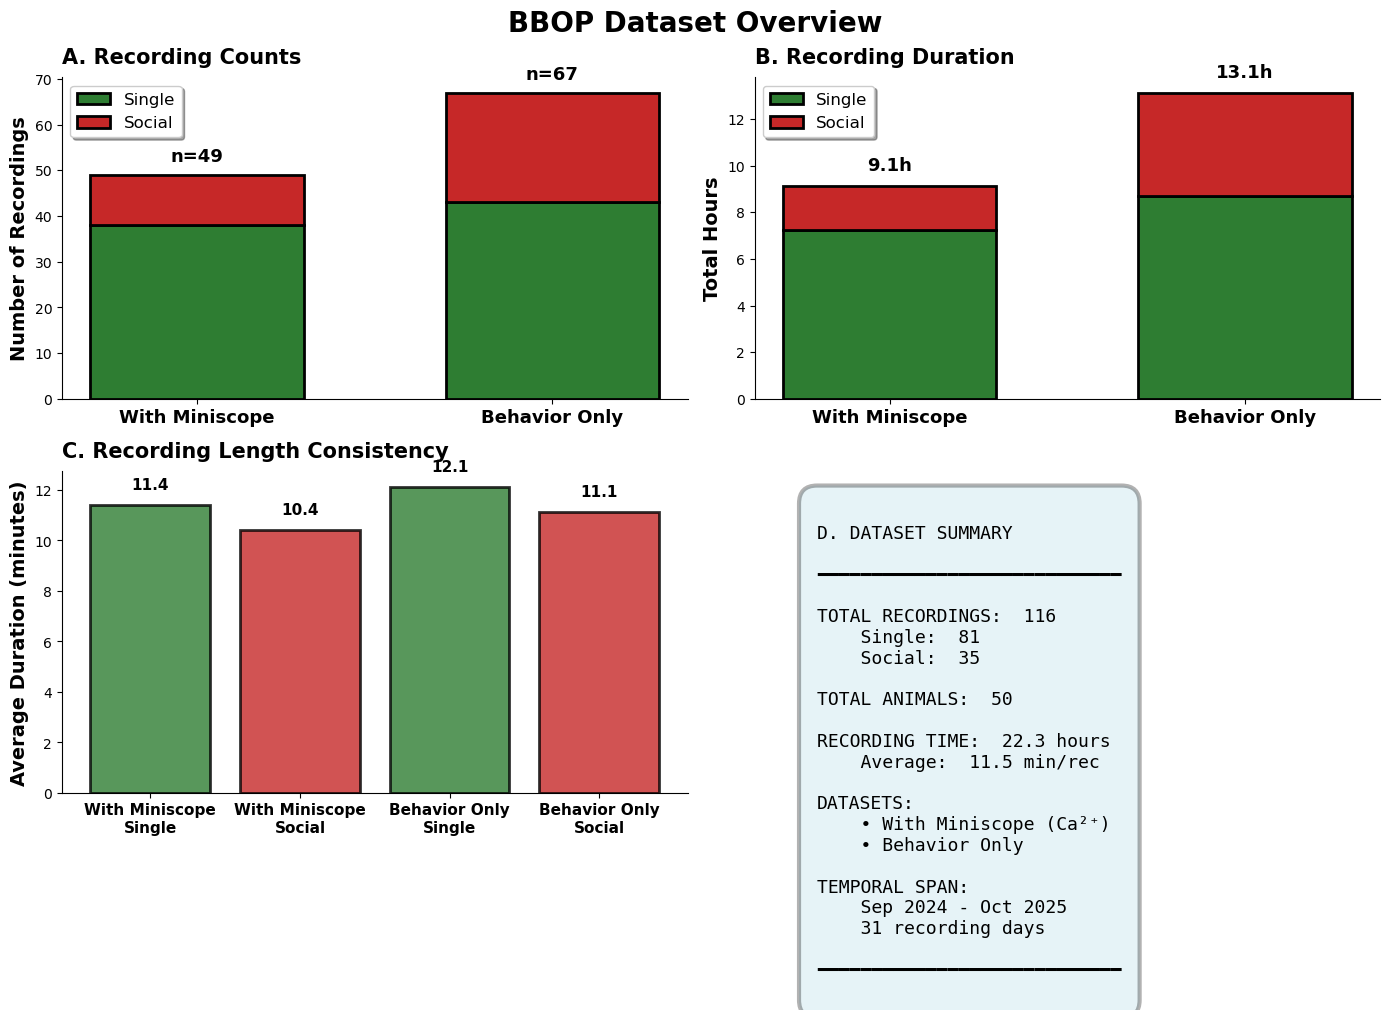

In [ ]:
"""
POSTER FIGURE - OPTION 1: Clean 2x2 Grid
=========================================
"Dataset at a Glance" - Four clear panels showing composition and scale
"""

import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# ============================================================================
# CONFIGURATION
# ============================================================================

# Output directory - CHANGE THIS TO WHERE YOU WANT FILES SAVED
# OUTPUT_DIR = "/home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis"
# "/hpc/group/tdunn/lq53/BBOP/25oct_sorted_scan/dataset_analysis"

# Add as many datasets as you want here - just add more tuples to the list
DATASETS = [
    ("/data/big_rim/uploade_ssh_mir_dataset/oct3v1_mini", "With Miniscope"),
    ("/data/big_rim/uploade_ssh_mir_dataset/oct3v1_beh_only", "Behavior Only"),
    # Add more datasets here in the future:
    # ("/path/to/dataset3", "Dataset 3 Description"),
    # ("/path/to/dataset4", "Dataset 4 Description"),
]

OUTPUT_FILE = "/home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/poster_option1.png"

# ============================================================================
# DATA COLLECTION
# ============================================================================

def get_recording_duration(rec_path):
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    if not os.path.exists(metadata_path):
        return None
    try:
        df = pd.read_csv(metadata_path)
        if 'totalTime' in df.columns:
            return float(df['totalTime'].iloc[0])
        for idx, row in df.iterrows():
            if 'totalTime' in str(row.values):
                for val in row.values:
                    try:
                        return float(val)
                    except:
                        continue
        return None
    except:
        return None

def analyze_dataset(base_path, dataset_name):
    stats = {
        'dataset_name': dataset_name,
        'conditions': {},
        'animals': set(),
        'dates': set(),
        'recording_details': [],
        'total_duration_seconds': 0,
    }
    
    if not os.path.exists(base_path):
        return stats
    
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            duration = get_recording_duration(rec_path)
            if duration:
                stats['total_duration_seconds'] += duration
            
            parts = rec_name.split('_')
            animals_in_rec = []
            date = None
            
            for part in parts:
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
            
            stats['recording_details'].append({
                'condition': condition,
                'duration_seconds': duration,
                'animals': animals_in_rec,
                'date': date,
            })
    
    return stats

print("Analyzing datasets...")
all_stats = []
for base_path, name in DATASETS:
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)

# ============================================================================
# CREATE FIGURE
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('BBOP Dataset Overview', fontsize=20, fontweight='bold', y=0.98)

# Colors
color_single = '#2E7D32'  # Green
color_social = '#C62828'  # Red
color_mini = '#1565C0'    # Blue
color_beh = '#EF6C00'     # Orange

# ============================================================================
# PANEL A: Recording Counts by Condition
# ============================================================================

ax = axes[0, 0]

dataset_names = [s['dataset_name'] for s in all_stats]
single_counts = [s['conditions'].get('single', 0) for s in all_stats]
social_counts = [s['conditions'].get('social', 0) for s in all_stats]

x = np.arange(len(dataset_names))
width = 0.6

bars1 = ax.bar(x, single_counts, width, label='Single', 
               color=color_single, edgecolor='black', linewidth=2)
bars2 = ax.bar(x, social_counts, width, bottom=single_counts,
               label='Social', color=color_social, edgecolor='black', linewidth=2)

ax.set_ylabel('Number of Recordings', fontsize=14, fontweight='bold')
ax.set_title('A. Recording Counts', fontsize=15, fontweight='bold', loc='left', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(dataset_names, fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add total labels
for i, (s1, s2) in enumerate(zip(single_counts, social_counts)):
    total = s1 + s2
    ax.text(i, total + 2, f'n={total}', ha='center', va='bottom', 
           fontweight='bold', fontsize=13)

# ============================================================================
# PANEL B: Recording Hours by Condition
# ============================================================================

ax = axes[0, 1]

# Calculate hours by condition for each dataset
single_hours = []
social_hours = []

for stats in all_stats:
    single_h = sum(r['duration_seconds'] for r in stats['recording_details'] 
                   if r['condition'] == 'single' and r['duration_seconds']) / 3600
    social_h = sum(r['duration_seconds'] for r in stats['recording_details'] 
                   if r['condition'] == 'social' and r['duration_seconds']) / 3600
    single_hours.append(single_h)
    social_hours.append(social_h)

bars1 = ax.bar(x, single_hours, width, label='Single', 
               color=color_single, edgecolor='black', linewidth=2)
bars2 = ax.bar(x, social_hours, width, bottom=single_hours,
               label='Social', color=color_social, edgecolor='black', linewidth=2)

ax.set_ylabel('Total Hours', fontsize=14, fontweight='bold')
ax.set_title('B. Recording Duration', fontsize=15, fontweight='bold', loc='left', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(dataset_names, fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add total labels
for i, (s1, s2) in enumerate(zip(single_hours, social_hours)):
    total = s1 + s2
    ax.text(i, total + 0.5, f'{total:.1f}h', ha='center', va='bottom', 
           fontweight='bold', fontsize=13)

# ============================================================================
# PANEL C: Average Duration by Condition
# ============================================================================

ax = axes[1, 0]

# Calculate average duration for each condition in each dataset
avg_durations = []
labels = []
colors_bars = []

for stats in all_stats:
    for condition in ['single', 'social']:
        durations = [r['duration_seconds']/60 for r in stats['recording_details'] 
                    if r['condition'] == condition and r['duration_seconds']]
        if durations:
            avg_durations.append(np.mean(durations))
            labels.append(f"{stats['dataset_name']}\n{condition.capitalize()}")
            colors_bars.append(color_single if condition == 'single' else color_social)

x_pos = np.arange(len(labels))
bars = ax.bar(x_pos, avg_durations, color=colors_bars, 
              edgecolor='black', linewidth=2, alpha=0.8)

ax.set_ylabel('Average Duration (minutes)', fontsize=14, fontweight='bold')
ax.set_title('C. Recording Length Consistency', fontsize=15, fontweight='bold', loc='left', pad=10)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, avg_durations)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}', 
           ha='center', va='bottom', fontweight='bold', fontsize=11)

# ============================================================================
# PANEL D: Summary Statistics
# ============================================================================

ax = axes[1, 1]
ax.axis('off')

# Calculate totals
total_recordings = sum(s['conditions'].get('single', 0) + s['conditions'].get('social', 0) 
                       for s in all_stats)
total_animals = len(set().union(*[s['animals'] for s in all_stats]))
total_hours = sum(s['total_duration_seconds'] for s in all_stats) / 3600
total_single = sum(s['conditions'].get('single', 0) for s in all_stats)
total_social = sum(s['conditions'].get('social', 0) for s in all_stats)

# Date range
all_dates = set().union(*[s['dates'] for s in all_stats])
all_dates_sorted = sorted(all_dates)
if all_dates_sorted:
    first_date = datetime.strptime(all_dates_sorted[0], '%Y%m%d').strftime('%b %Y')
    last_date = datetime.strptime(all_dates_sorted[-1], '%Y%m%d').strftime('%b %Y')
    date_range = f"{first_date} - {last_date}"
else:
    date_range = "N/A"

summary = f"""
D. DATASET SUMMARY

━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TOTAL RECORDINGS:  {total_recordings}
    Single:  {total_single}
    Social:  {total_social}

TOTAL ANIMALS:  {total_animals}

RECORDING TIME:  {total_hours:.1f} hours
    Average:  {total_hours*60/total_recordings:.1f} min/rec

DATASETS:
    • With Miniscope (Ca²⁺)
    • Behavior Only

TEMPORAL SPAN:
    {date_range}
    {len(all_dates)} recording days

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

ax.text(0.1, 0.9, summary, transform=ax.transAxes,
       fontsize=13, verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round,pad=1', facecolor='lightblue', 
                alpha=0.3, edgecolor='black', linewidth=3))

# ============================================================================
# SAVE
# ============================================================================

plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Option 1 saved: {OUTPUT_FILE}")
plt.show()

Analyzing datasets...
✓ Option 2 saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/poster_option1.png


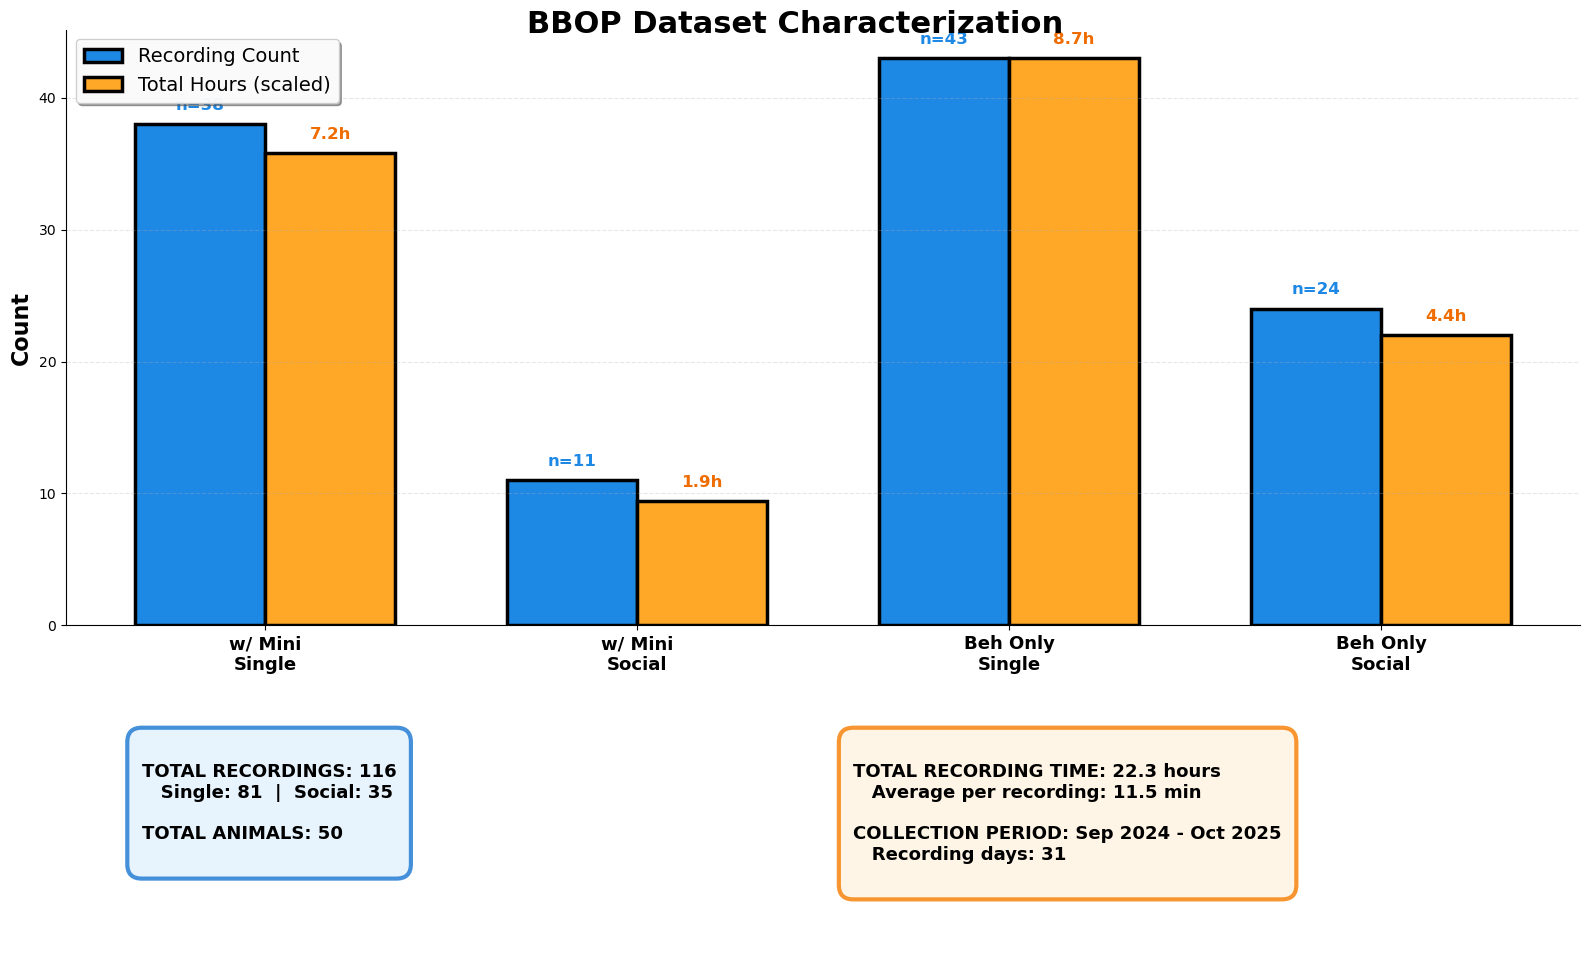

In [9]:
"""
POSTER FIGURE - OPTION 2: Single Powerful Visualization
========================================================
One clear grouped bar chart showing everything at once
"""

import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# ============================================================================
# CONFIGURATION
# ============================================================================

# DATASETS = [
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_social_mini", "With Miniscope"),
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_beh_only", "Behavior Only"),
# ]

# OUTPUT_FILE = "/hpc/group/tdunn/lq53/BBOP/25oct_sorted_scan/dataset_analysis/poster_option2.png"

# ============================================================================
# DATA COLLECTION
# ============================================================================

def get_recording_duration(rec_path):
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    if not os.path.exists(metadata_path):
        return None
    try:
        df = pd.read_csv(metadata_path)
        if 'totalTime' in df.columns:
            return float(df['totalTime'].iloc[0])
        for idx, row in df.iterrows():
            if 'totalTime' in str(row.values):
                for val in row.values:
                    try:
                        return float(val)
                    except:
                        continue
        return None
    except:
        return None

def analyze_dataset(base_path, dataset_name):
    stats = {
        'dataset_name': dataset_name,
        'conditions': {},
        'animals': set(),
        'dates': set(),
        'recording_details': [],
        'total_duration_seconds': 0,
    }
    
    if not os.path.exists(base_path):
        return stats
    
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            duration = get_recording_duration(rec_path)
            if duration:
                stats['total_duration_seconds'] += duration
            
            parts = rec_name.split('_')
            animals_in_rec = []
            date = None
            
            for part in parts:
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
            
            stats['recording_details'].append({
                'condition': condition,
                'duration_seconds': duration,
                'animals': animals_in_rec,
                'date': date,
            })
    
    return stats

print("Analyzing datasets...")
all_stats = []
for base_path, name in DATASETS:
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)

# ============================================================================
# CREATE FIGURE
# ============================================================================

fig = plt.figure(figsize=(16, 10))

# Create main plot area (top 70%)
ax_main = plt.subplot2grid((3, 1), (0, 0), rowspan=2)

# Create summary area (bottom 30%)
ax_summary = plt.subplot2grid((3, 1), (2, 0))
ax_summary.axis('off')

fig.suptitle('BBOP Dataset Characterization', fontsize=22, fontweight='bold', y=0.96)

# ============================================================================
# MAIN CHART: Grouped bars for Count and Hours
# ============================================================================

# Prepare data
categories = []
counts = []
hours = []

for stats in all_stats:
    for condition in ['single', 'social']:
        # Count
        count = stats['conditions'].get(condition, 0)
        counts.append(count)
        
        # Hours
        hrs = sum(r['duration_seconds'] for r in stats['recording_details'] 
                 if r['condition'] == condition and r['duration_seconds']) / 3600
        hours.append(hrs)
        
        # Label
        dataset_short = 'w/ Mini' if 'Miniscope' in stats['dataset_name'] else 'Beh Only'
        categories.append(f"{dataset_short}\n{condition.capitalize()}")

# Normalize hours to same scale as counts for visualization
max_count = max(counts)
max_hours = max(hours)
hours_scaled = [h * (max_count / max_hours) for h in hours]

# Plot
x = np.arange(len(categories))
width = 0.35

bars1 = ax_main.bar(x - width/2, counts, width, label='Recording Count', 
                   color='#1E88E5', edgecolor='black', linewidth=2.5)
bars2 = ax_main.bar(x + width/2, hours_scaled, width, label='Total Hours (scaled)', 
                   color='#FFA726', edgecolor='black', linewidth=2.5)

ax_main.set_ylabel('Count', fontsize=16, fontweight='bold')
ax_main.set_xticks(x)
ax_main.set_xticklabels(categories, fontsize=13, fontweight='bold')
ax_main.legend(loc='upper left', fontsize=14, frameon=True, shadow=True, 
              fancybox=True, framealpha=0.95)
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_main.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars1, counts)):
    ax_main.text(bar.get_x() + bar.get_width()/2, count + max_count*0.02, 
                f'n={count}', ha='center', va='bottom', 
                fontweight='bold', fontsize=12, color='#1E88E5')

for i, (bar, hrs) in enumerate(zip(bars2, hours)):
    ax_main.text(bar.get_x() + bar.get_width()/2, hours_scaled[i] + max_count*0.02, 
                f'{hrs:.1f}h', ha='center', va='bottom', 
                fontweight='bold', fontsize=12, color='#EF6C00')

# ============================================================================
# SUMMARY SECTION
# ============================================================================

# Calculate totals
total_recordings = sum(counts)
total_animals = len(set().union(*[s['animals'] for s in all_stats]))
total_hours = sum(hours)
total_single = sum(s['conditions'].get('single', 0) for s in all_stats)
total_social = sum(s['conditions'].get('social', 0) for s in all_stats)

# Date range
all_dates = set().union(*[s['dates'] for s in all_stats])
all_dates_sorted = sorted(all_dates)
if all_dates_sorted:
    first_date = datetime.strptime(all_dates_sorted[0], '%Y%m%d').strftime('%b %Y')
    last_date = datetime.strptime(all_dates_sorted[-1], '%Y%m%d').strftime('%b %Y')
    date_range = f"{first_date} - {last_date}"
else:
    date_range = "N/A"

# Create summary text in columns
summary_left = f"""
TOTAL RECORDINGS: {total_recordings}
   Single: {total_single}  |  Social: {total_social}

TOTAL ANIMALS: {total_animals}
"""

summary_right = f"""
TOTAL RECORDING TIME: {total_hours:.1f} hours
   Average per recording: {total_hours*60/total_recordings:.1f} min

COLLECTION PERIOD: {date_range}
   Recording days: {len(all_dates)}
"""

# Place summary text
ax_summary.text(0.05, 0.8, summary_left, transform=ax_summary.transAxes,
               fontsize=13, verticalalignment='top', fontfamily='sans-serif',
               fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.8', facecolor='#E3F2FD', 
                        alpha=0.8, edgecolor='#1976D2', linewidth=3))

ax_summary.text(0.52, 0.8, summary_right, transform=ax_summary.transAxes,
               fontsize=13, verticalalignment='top', fontfamily='sans-serif',
               fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF3E0', 
                        alpha=0.8, edgecolor='#F57C00', linewidth=3))

# ============================================================================
# SAVE
# ============================================================================

plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Option 2 saved: {OUTPUT_FILE}")
plt.show()

Analyzing datasets...
✓ Option 3 saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/poster_option1.png


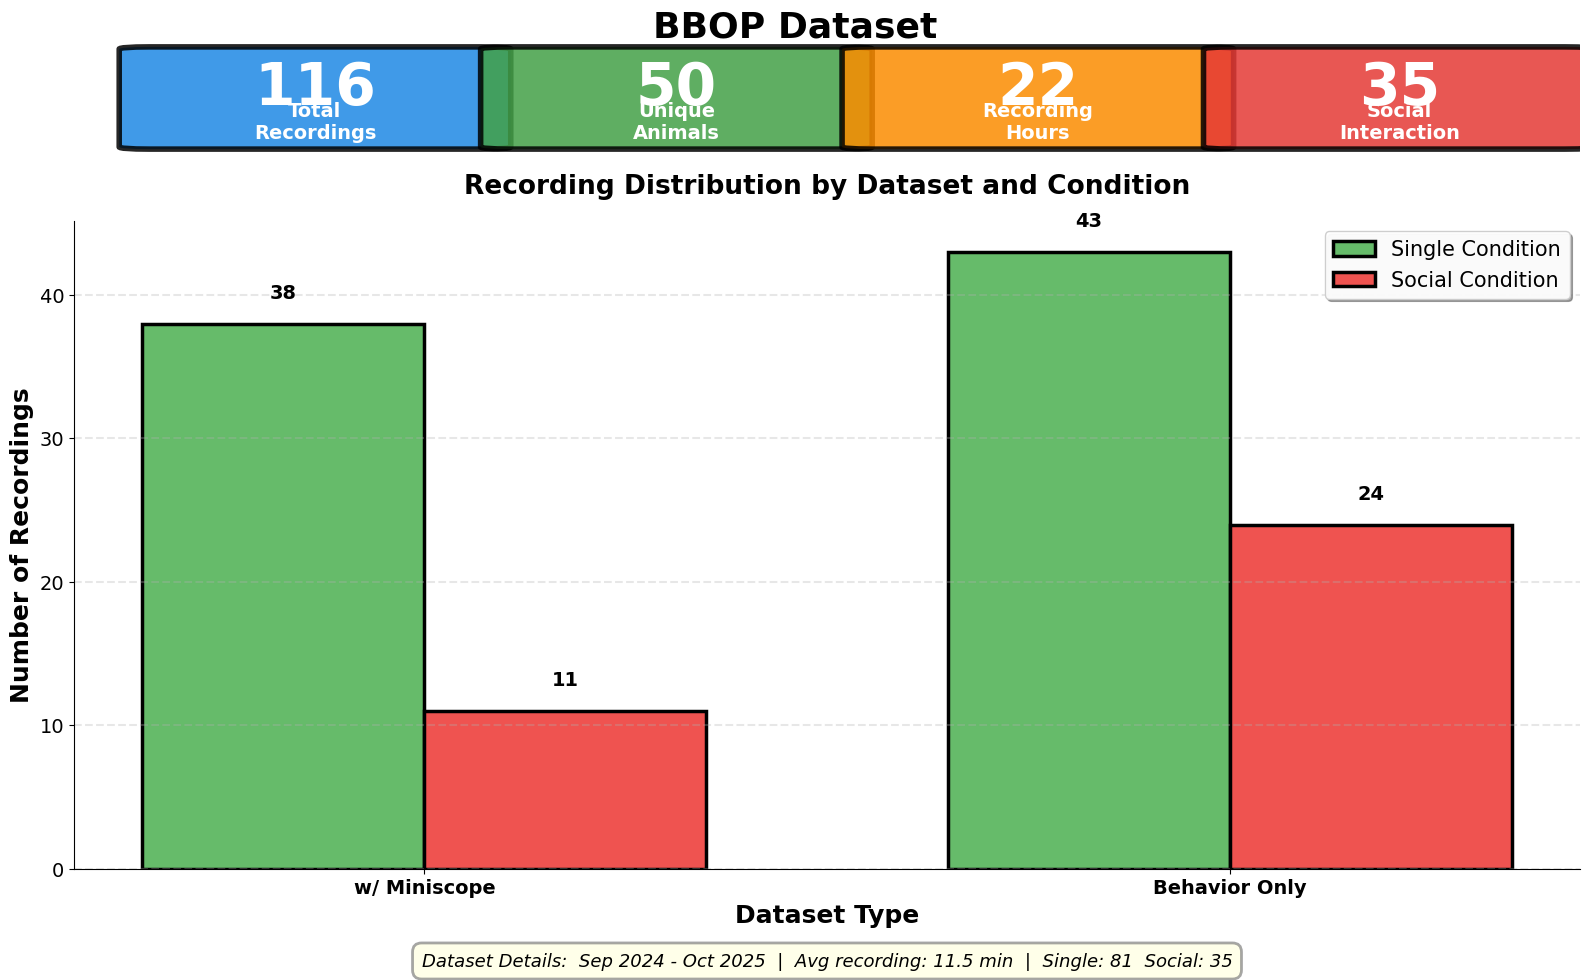

In [3]:
"""
POSTER FIGURE - OPTION 3: Infographic Style
============================================
Big impactful numbers at top, one clear chart below
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
from datetime import datetime

# ============================================================================
# CONFIGURATION
# ============================================================================

# DATASETS = [
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_social_mini", "With Miniscope"),
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_beh_only", "Behavior Only"),
# ]

# OUTPUT_FILE = "/hpc/group/tdunn/lq53/BBOP/25oct_sorted_scan/dataset_analysis/poster_option3.png"

# ============================================================================
# DATA COLLECTION
# ============================================================================

def get_recording_duration(rec_path):
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    if not os.path.exists(metadata_path):
        return None
    try:
        df = pd.read_csv(metadata_path)
        if 'totalTime' in df.columns:
            return float(df['totalTime'].iloc[0])
        for idx, row in df.iterrows():
            if 'totalTime' in str(row.values):
                for val in row.values:
                    try:
                        return float(val)
                    except:
                        continue
        return None
    except:
        return None

def analyze_dataset(base_path, dataset_name):
    stats = {
        'dataset_name': dataset_name,
        'conditions': {},
        'animals': set(),
        'dates': set(),
        'recording_details': [],
        'total_duration_seconds': 0,
    }
    
    if not os.path.exists(base_path):
        return stats
    
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            duration = get_recording_duration(rec_path)
            if duration:
                stats['total_duration_seconds'] += duration
            
            parts = rec_name.split('_')
            animals_in_rec = []
            date = None
            
            for part in parts:
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
            
            stats['recording_details'].append({
                'condition': condition,
                'duration_seconds': duration,
                'animals': animals_in_rec,
                'date': date,
            })
    
    return stats

print("Analyzing datasets...")
all_stats = []
for base_path, name in DATASETS:
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)

# ============================================================================
# CALCULATE KEY METRICS
# ============================================================================

total_recordings = sum(s['conditions'].get('single', 0) + s['conditions'].get('social', 0) 
                       for s in all_stats)
total_animals = len(set().union(*[s['animals'] for s in all_stats]))
total_hours = sum(s['total_duration_seconds'] for s in all_stats) / 3600
total_social = sum(s['conditions'].get('social', 0) for s in all_stats)
total_single = sum(s['conditions'].get('single', 0) for s in all_stats)

# Date range
all_dates = set().union(*[s['dates'] for s in all_stats])
all_dates_sorted = sorted(all_dates)
if all_dates_sorted:
    first_date = datetime.strptime(all_dates_sorted[0], '%Y%m%d').strftime('%b %Y')
    last_date = datetime.strptime(all_dates_sorted[-1], '%Y%m%d').strftime('%b %Y')
    date_span = f"{first_date} - {last_date}"
else:
    date_span = "N/A"

# ============================================================================
# CREATE FIGURE
# ============================================================================

fig = plt.figure(figsize=(16, 10))

# Title
fig.suptitle('BBOP Dataset', fontsize=26, fontweight='bold', y=0.97)

# Create layout: top section for big numbers, bottom for chart
ax_numbers = plt.subplot2grid((5, 4), (0, 0), colspan=4, rowspan=1)
ax_numbers.axis('off')

ax_chart = plt.subplot2grid((5, 4), (1, 0), colspan=4, rowspan=4)

# ============================================================================
# TOP SECTION: Big Numbers in Boxes
# ============================================================================

metrics = [
    (total_recordings, 'Total\nRecordings', '#1E88E5'),
    (total_animals, 'Unique\nAnimals', '#43A047'),
    (f'{total_hours:.0f}', 'Recording\nHours', '#FB8C00'),
    (total_social, 'Social\nInteraction', '#E53935'),
]

box_width = 0.22
box_height = 0.85
y_pos = 0.1

for i, (value, label, color) in enumerate(metrics):
    x_pos = 0.05 + i * 0.24
    
    # Create fancy box
    fancy_box = FancyBboxPatch((x_pos, y_pos), box_width, box_height,
                              boxstyle="round,pad=0.02", 
                              transform=ax_numbers.transAxes,
                              facecolor=color, edgecolor='black', 
                              linewidth=4, alpha=0.85)
    ax_numbers.add_patch(fancy_box)
    
    # Add number (large)
    ax_numbers.text(x_pos + box_width/2, y_pos + box_height*0.6, 
                   str(value), transform=ax_numbers.transAxes,
                   fontsize=42, fontweight='bold', color='white',
                   ha='center', va='center')
    
    # Add label (small)
    ax_numbers.text(x_pos + box_width/2, y_pos + box_height*0.25, 
                   label, transform=ax_numbers.transAxes,
                   fontsize=14, fontweight='bold', color='white',
                   ha='center', va='center')

# ============================================================================
# BOTTOM SECTION: Detailed Breakdown Chart
# ============================================================================

# Prepare data for grouped bar chart
categories = []
single_vals = []
social_vals = []
colors_dataset = []

for stats in all_stats:
    dataset_short = 'w/ Miniscope' if 'Miniscope' in stats['dataset_name'] else 'Behavior Only'
    categories.append(dataset_short)
    
    # Get counts
    single_vals.append(stats['conditions'].get('single', 0))
    social_vals.append(stats['conditions'].get('social', 0))
    
    # Get hours
    single_h = sum(r['duration_seconds'] for r in stats['recording_details'] 
                   if r['condition'] == 'single' and r['duration_seconds']) / 3600
    social_h = sum(r['duration_seconds'] for r in stats['recording_details'] 
                   if r['condition'] == 'social' and r['duration_seconds']) / 3600

# Create grouped bars
x = np.arange(len(categories))
width = 0.35

bars1 = ax_chart.bar(x - width/2, single_vals, width, label='Single Condition', 
                    color='#66BB6A', edgecolor='black', linewidth=2.5)
bars2 = ax_chart.bar(x + width/2, social_vals, width, label='Social Condition', 
                    color='#EF5350', edgecolor='black', linewidth=2.5)

ax_chart.set_ylabel('Number of Recordings', fontsize=18, fontweight='bold')
ax_chart.set_xlabel('Dataset Type', fontsize=18, fontweight='bold')
ax_chart.set_title('Recording Distribution by Dataset and Condition', 
                  fontsize=19, fontweight='bold', pad=20)
ax_chart.set_xticks(x)
ax_chart.set_xticklabels(categories, fontsize=16, fontweight='bold')
ax_chart.legend(loc='upper right', fontsize=15, frameon=True, shadow=True,
               fancybox=True, framealpha=0.95)
ax_chart.spines['top'].set_visible(False)
ax_chart.spines['right'].set_visible(False)
ax_chart.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1.5)
ax_chart.tick_params(axis='both', labelsize=14)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax_chart.text(bar.get_x() + bar.get_width()/2., height + 1.5,
                     f'{int(height)}',
                     ha='center', va='bottom', fontweight='bold', fontsize=14)

# Add dataset info text
info_text = f"""Dataset Details:  {date_span}  |  Avg recording: {total_hours*60/total_recordings:.1f} min  |  Single: {total_single}  Social: {total_social}"""

ax_chart.text(0.5, -0.15, info_text, transform=ax_chart.transAxes,
             fontsize=13, ha='center', style='italic',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                      alpha=0.7, edgecolor='gray', linewidth=2))

# ============================================================================
# SAVE
# ============================================================================

plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Option 3 saved: {OUTPUT_FILE}")
plt.show()

Analyzing datasets...

Data summary:

With Miniscope:
  single: 38 recordings, 7.2 hours
  social: 11 recordings, 1.9 hours

Behavior Only:
  single: 43 recordings, 8.7 hours
  social: 24 recordings, 4.4 hours

✓ Clean figure saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/poster_option1.png

All data properly displayed:
  - Panel A: Recording counts for all 4 conditions
  - Panel B: Recording hours for all 4 conditions
  - Panel C: Side-by-side comparison
  - Panel D: Detailed numerical summary


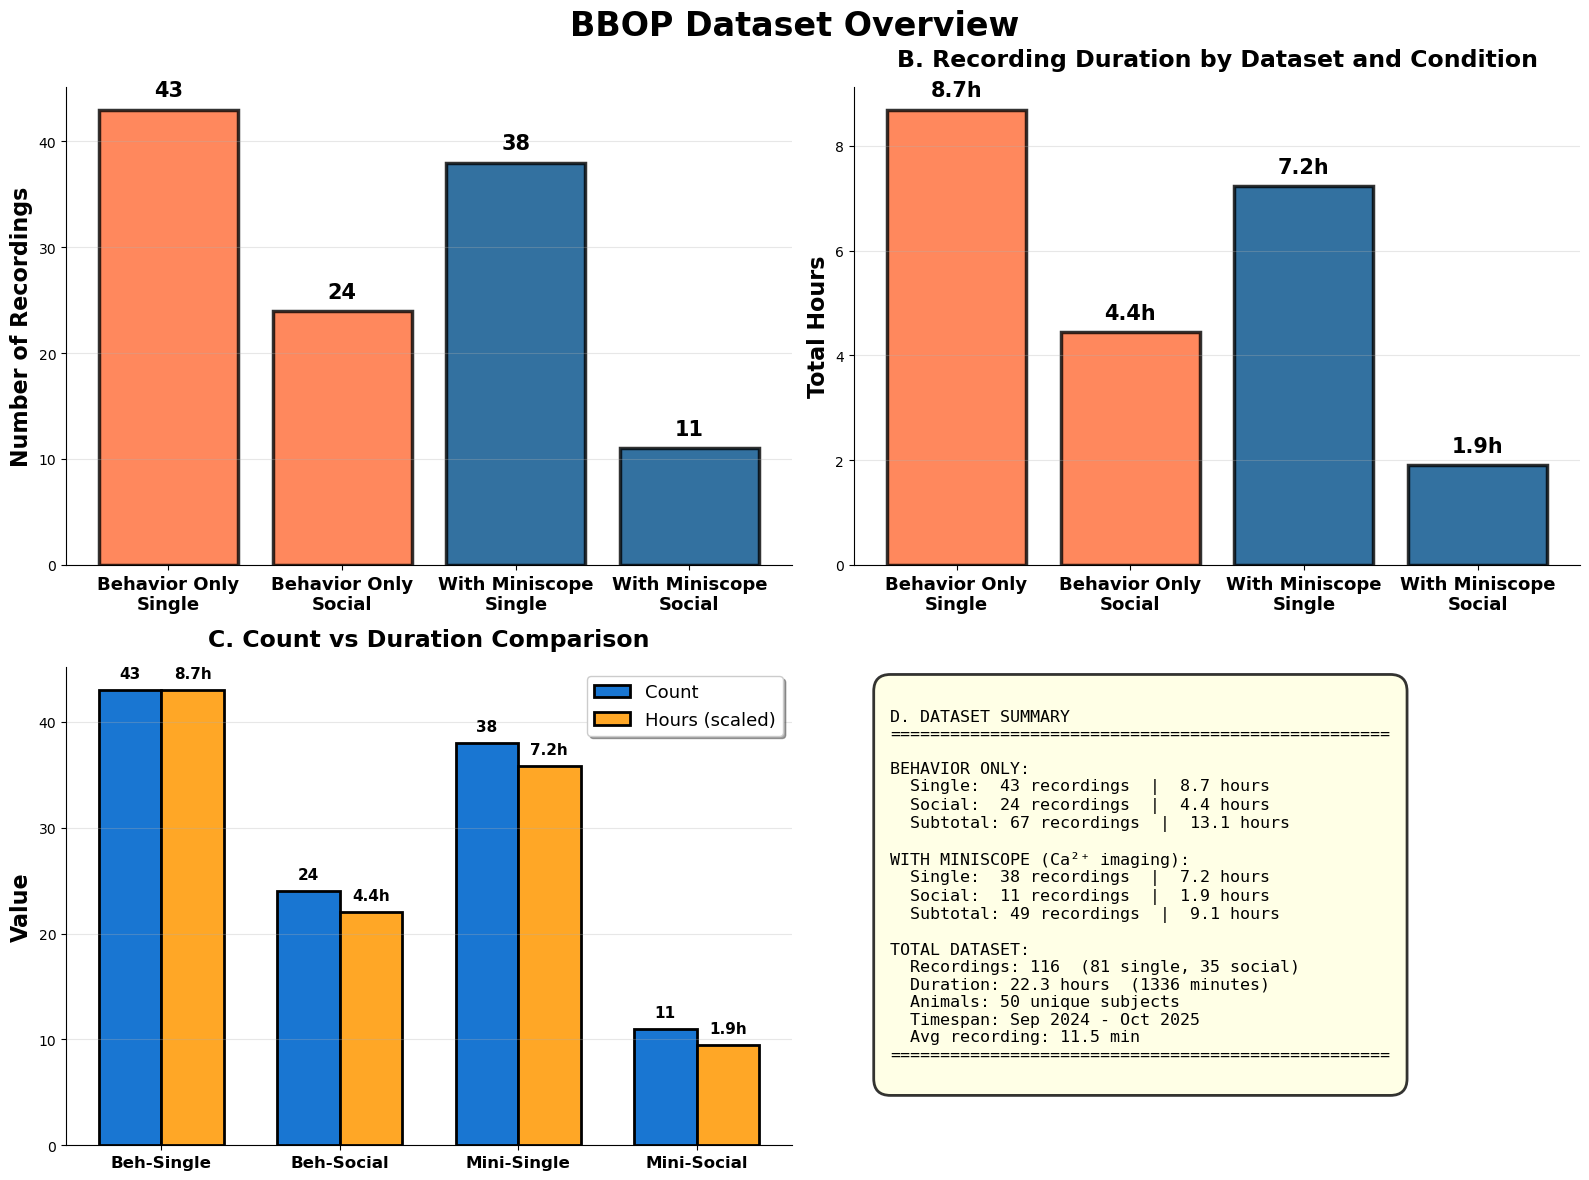

In [13]:
"""
POSTER FIGURE - CLEAN VERSION
==============================
Properly showing both recording counts AND hours for all conditions
"""

import os
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# ============================================================================
# CONFIGURATION
# ============================================================================

# DATASETS = [
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_social_mini", "With Miniscope"),
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_beh_only", "Behavior Only"),
# ]

# OUTPUT_FILE = "/hpc/group/tdunn/lq53/BBOP/25oct_sorted_scan/dataset_analysis/poster_figure_clean.png"

# ============================================================================
# DATA COLLECTION
# ============================================================================

def get_recording_duration(rec_path):
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    if not os.path.exists(metadata_path):
        return None
    try:
        df = pd.read_csv(metadata_path)
        if 'totalTime' in df.columns:
            return float(df['totalTime'].iloc[0])
        for idx, row in df.iterrows():
            if 'totalTime' in str(row.values):
                for val in row.values:
                    try:
                        return float(val)
                    except:
                        continue
        return None
    except:
        return None

def analyze_dataset(base_path, dataset_name):
    stats = {
        'dataset_name': dataset_name,
        'conditions': {},
        'animals': set(),
        'dates': set(),
        'recording_details': [],
    }
    
    if not os.path.exists(base_path):
        return stats
    
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            duration = get_recording_duration(rec_path)
            
            parts = rec_name.split('_')
            animals_in_rec = []
            date = None
            
            for part in parts:
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
            
            stats['recording_details'].append({
                'condition': condition,
                'duration_seconds': duration,
                'animals': animals_in_rec,
                'date': date,
            })
    
    return stats

print("Analyzing datasets...")
all_stats = []
for base_path, name in DATASETS:
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)

# ============================================================================
# PREPARE DATA FOR VISUALIZATION
# ============================================================================

# Create data structure: [dataset][condition] = {count, hours}
data = {}

for stats in all_stats:
    dataset_name = stats['dataset_name']
    data[dataset_name] = {}
    
    for condition in ['single', 'social']:
        # Count
        count = stats['conditions'].get(condition, 0)
        
        # Hours
        total_seconds = sum(r['duration_seconds'] for r in stats['recording_details'] 
                           if r['condition'] == condition and r['duration_seconds'] is not None)
        hours = total_seconds / 3600
        
        data[dataset_name][condition] = {
            'count': count,
            'hours': hours
        }

# Print data for verification
print("\nData summary:")
for dataset in data:
    print(f"\n{dataset}:")
    for condition in data[dataset]:
        print(f"  {condition}: {data[dataset][condition]['count']} recordings, {data[dataset][condition]['hours']:.1f} hours")

# ============================================================================
# CREATE FIGURE
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('BBOP Dataset Overview', fontsize=24, fontweight='bold', y=0.98)

# Colors
color_beh = '#FF6B35'      # Orange for Behavior Only
color_mini = '#004E89'     # Blue for With Miniscope
color_single = '#7CB342'   # Green for single
color_social = '#E53935'   # Red for social

# ============================================================================
# PANEL A: Recording Counts
# ============================================================================

ax = axes[0, 0]

categories = ['Behavior Only\nSingle', 'Behavior Only\nSocial', 
              'With Miniscope\nSingle', 'With Miniscope\nSocial']
counts = [
    data['Behavior Only']['single']['count'],
    data['Behavior Only']['social']['count'],
    data['With Miniscope']['single']['count'],
    data['With Miniscope']['social']['count']
]
colors = [color_beh, color_beh, color_mini, color_mini]

x = np.arange(len(categories))
bars = ax.bar(x, counts, color=colors, edgecolor='black', linewidth=2.5, alpha=0.8)

ax.set_ylabel('Number of Recordings', fontsize=16, fontweight='bold')
# ax.set_title('A. Recording Counts by Dataset and Condition', fontsize=17, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(bar.get_x() + bar.get_width()/2, count + max(counts)*0.02, 
           f'{count}', ha='center', va='bottom', 
           fontweight='bold', fontsize=15)

# ============================================================================
# PANEL B: Recording Hours
# ============================================================================

ax = axes[0, 1]

hours = [
    data['Behavior Only']['single']['hours'],
    data['Behavior Only']['social']['hours'],
    data['With Miniscope']['single']['hours'],
    data['With Miniscope']['social']['hours']
]

bars = ax.bar(x, hours, color=colors, edgecolor='black', linewidth=2.5, alpha=0.8)

ax.set_ylabel('Total Hours', fontsize=16, fontweight='bold')
ax.set_title('B. Recording Duration by Dataset and Condition', fontsize=17, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, hrs) in enumerate(zip(bars, hours)):
    ax.text(bar.get_x() + bar.get_width()/2, hrs + max(hours)*0.02, 
           f'{hrs:.1f}h', ha='center', va='bottom', 
           fontweight='bold', fontsize=15)

# ============================================================================
# PANEL C: Side-by-side comparison (Count vs Hours per condition)
# ============================================================================

ax = axes[1, 0]

# Show both count and hours for each dataset/condition
conditions_short = ['Beh-Single', 'Beh-Social', 'Mini-Single', 'Mini-Social']
x_pos = np.arange(len(conditions_short))
width = 0.35

# Normalize hours to be on similar scale as counts for dual display
max_count = max(counts)
max_hour = max(hours)
hours_scaled = [h * (max_count / max_hour) for h in hours]

bars1 = ax.bar(x_pos - width/2, counts, width, label='Count', 
              color='#1976D2', edgecolor='black', linewidth=2)
bars2 = ax.bar(x_pos + width/2, hours_scaled, width, label='Hours (scaled)', 
              color='#FFA726', edgecolor='black', linewidth=2)

ax.set_ylabel('Value', fontsize=16, fontweight='bold')
ax.set_title('C. Count vs Duration Comparison', fontsize=17, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(conditions_short, fontsize=12, fontweight='bold')
ax.legend(fontsize=13, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# Add real values
for i, (bar, count) in enumerate(zip(bars1, counts)):
    ax.text(bar.get_x() + bar.get_width()/2, count + max_count*0.02, 
           f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=11)

for i, (bar, hrs) in enumerate(zip(bars2, hours)):
    ax.text(bar.get_x() + bar.get_width()/2, hours_scaled[i] + max_count*0.02, 
           f'{hrs:.1f}h', ha='center', va='bottom', fontweight='bold', fontsize=11)

# ============================================================================
# PANEL D: Summary Table
# ============================================================================

ax = axes[1, 1]
ax.axis('off')

# Calculate totals
total_recordings = sum(counts)
total_hours = sum(hours)
total_animals = len(set().union(*[s['animals'] for s in all_stats]))
total_single = data['Behavior Only']['single']['count'] + data['With Miniscope']['single']['count']
total_social = data['Behavior Only']['social']['count'] + data['With Miniscope']['social']['count']

# Date range
all_dates = set().union(*[s['dates'] for s in all_stats])
all_dates_sorted = sorted(all_dates)
if all_dates_sorted:
    first_date = datetime.strptime(all_dates_sorted[0], '%Y%m%d').strftime('%b %Y')
    last_date = datetime.strptime(all_dates_sorted[-1], '%Y%m%d').strftime('%b %Y')
    date_range = f"{first_date} - {last_date}"
else:
    date_range = "N/A"

# Create detailed table
table_data = f"""
D. DATASET SUMMARY
{'='*50}

BEHAVIOR ONLY:
  Single:  {data['Behavior Only']['single']['count']} recordings  |  {data['Behavior Only']['single']['hours']:.1f} hours
  Social:  {data['Behavior Only']['social']['count']} recordings  |  {data['Behavior Only']['social']['hours']:.1f} hours
  Subtotal: {data['Behavior Only']['single']['count'] + data['Behavior Only']['social']['count']} recordings  |  {data['Behavior Only']['single']['hours'] + data['Behavior Only']['social']['hours']:.1f} hours

WITH MINISCOPE (Ca²⁺ imaging):
  Single:  {data['With Miniscope']['single']['count']} recordings  |  {data['With Miniscope']['single']['hours']:.1f} hours
  Social:  {data['With Miniscope']['social']['count']} recordings  |  {data['With Miniscope']['social']['hours']:.1f} hours
  Subtotal: {data['With Miniscope']['single']['count'] + data['With Miniscope']['social']['count']} recordings  |  {data['With Miniscope']['single']['hours'] + data['With Miniscope']['social']['hours']:.1f} hours

TOTAL DATASET:
  Recordings: {total_recordings}  ({total_single} single, {total_social} social)
  Duration: {total_hours:.1f} hours  ({total_hours*60:.0f} minutes)
  Animals: {total_animals} unique subjects
  Timespan: {date_range}
  Avg recording: {total_hours*60/total_recordings:.1f} min
{'='*50}
"""

ax.text(0.05, 0.95, table_data, transform=ax.transAxes,
       fontsize=12, verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round,pad=1', facecolor='lightyellow', 
                alpha=0.8, edgecolor='black', linewidth=2))

# ============================================================================
# SAVE
# ============================================================================

plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ Clean figure saved: {OUTPUT_FILE}")
print("\nAll data properly displayed:")
print(f"  - Panel A: Recording counts for all 4 conditions")
print(f"  - Panel B: Recording hours for all 4 conditions")
print(f"  - Panel C: Side-by-side comparison")
print(f"  - Panel D: Detailed numerical summary")
plt.show()

Analyzing datasets...

Metrics:
  Recordings: 116
  Animals: 50
  Hours: 22.3
  Social: 35

✓ Final poster figure saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/poster_option1.png

Final improvements:
  ✓ Gaps between banner boxes (better visual separation)
  ✓ Lighter colors to match blue poster theme
  ✓ Removed y-axis entirely (cleaner)
  ✓ X-axis labels restored (meaningful context)
  ✓ Better overall spacing and proportions
  ✓ Ready for poster integration!


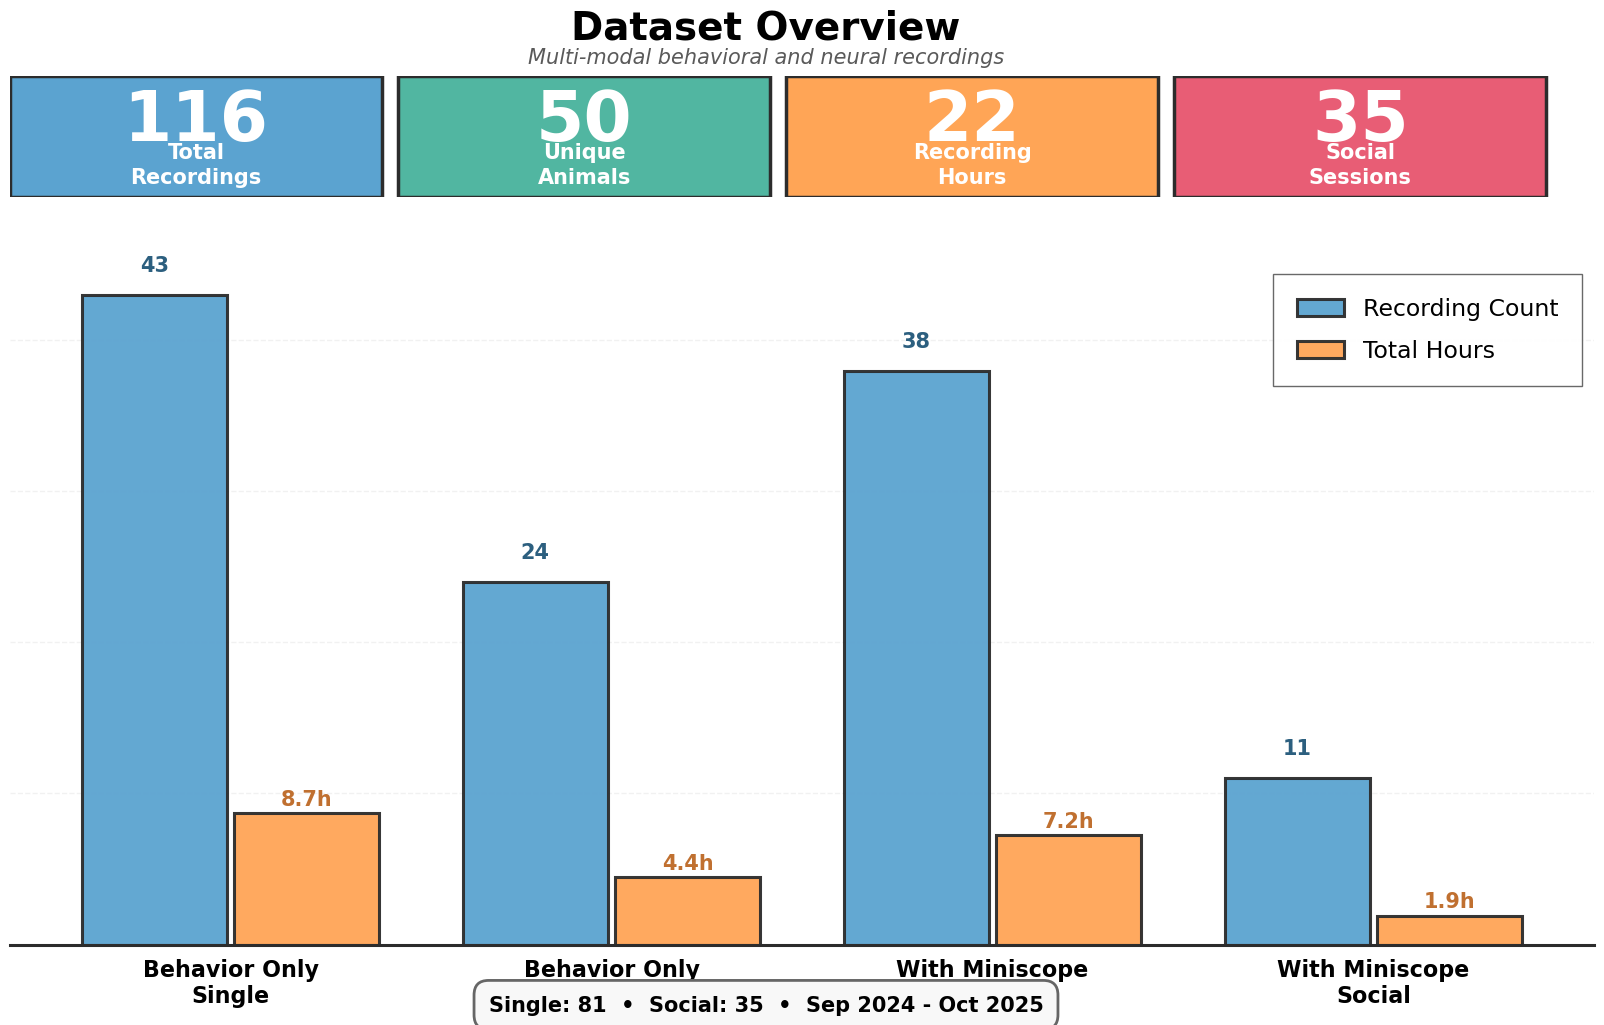

In [18]:
"""
POSTER FIGURE - FINAL VERSION
==============================
Changes for poster integration:
- Small gaps between banner boxes (cleaner)
- Lighter, softer colors to match blue poster theme
- No y-axis (cleaner look)
- X-axis labels back (meaningful context)
- Better overall spacing and proportions
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from datetime import datetime

# ============================================================================
# CONFIGURATION
# ============================================================================

# DATASETS = [
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_social_mini", "With Miniscope"),
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_beh_only", "Behavior Only"),
# ]

# OUTPUT_FILE = "/mnt/user-data/outputs/poster_figure_final.png"

# ============================================================================
# DATA COLLECTION
# ============================================================================

def get_recording_duration(rec_path):
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    if not os.path.exists(metadata_path):
        return None
    try:
        df = pd.read_csv(metadata_path)
        if 'totalTime' in df.columns:
            return float(df['totalTime'].iloc[0])
        for idx, row in df.iterrows():
            if 'totalTime' in str(row.values):
                for val in row.values:
                    try:
                        return float(val)
                    except:
                        continue
        return None
    except:
        return None

def analyze_dataset(base_path, dataset_name):
    stats = {
        'dataset_name': dataset_name,
        'conditions': {},
        'animals': set(),
        'dates': set(),
        'recording_details': [],
    }
    
    if not os.path.exists(base_path):
        return stats
    
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            duration = get_recording_duration(rec_path)
            
            parts = rec_name.split('_')
            animals_in_rec = []
            date = None
            
            for part in parts:
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
            
            stats['recording_details'].append({
                'condition': condition,
                'duration_seconds': duration,
                'animals': animals_in_rec,
                'date': date,
            })
    
    return stats

print("Analyzing datasets...")
all_stats = []
for base_path, name in DATASETS:
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)

# ============================================================================
# CALCULATE METRICS
# ============================================================================

# Prepare data structure
data = {}
for stats in all_stats:
    dataset_name = stats['dataset_name']
    data[dataset_name] = {}
    
    for condition in ['single', 'social']:
        count = stats['conditions'].get(condition, 0)
        total_seconds = sum(r['duration_seconds'] for r in stats['recording_details'] 
                           if r['condition'] == condition and r['duration_seconds'] is not None)
        hours = total_seconds / 3600
        
        data[dataset_name][condition] = {
            'count': count,
            'hours': hours
        }

# Calculate totals
total_recordings = sum(s['conditions'].get('single', 0) + s['conditions'].get('social', 0) 
                       for s in all_stats)
total_animals = len(set().union(*[s['animals'] for s in all_stats]))
total_hours = sum(sum(r['duration_seconds'] for r in s['recording_details'] 
                      if r['duration_seconds'] is not None) / 3600 for s in all_stats)
total_social = sum(s['conditions'].get('social', 0) for s in all_stats)
total_single = sum(s['conditions'].get('single', 0) for s in all_stats)

# Date range
all_dates = set().union(*[s['dates'] for s in all_stats])
all_dates_sorted = sorted(all_dates)
if all_dates_sorted:
    first_date = datetime.strptime(all_dates_sorted[0], '%Y%m%d').strftime('%b %Y')
    last_date = datetime.strptime(all_dates_sorted[-1], '%Y%m%d').strftime('%b %Y')
    date_span = f"{first_date} - {last_date}"
else:
    date_span = "N/A"

print(f"\nMetrics:")
print(f"  Recordings: {total_recordings}")
print(f"  Animals: {total_animals}")
print(f"  Hours: {total_hours:.1f}")
print(f"  Social: {total_social}")

# ============================================================================
# CREATE FIGURE
# ============================================================================

fig = plt.figure(figsize=(18, 11))

# Better spacing - give more room for the chart
ax_banner = plt.axes([0.08, 0.78, 0.88, 0.11])  # Slightly wider banner
ax_banner.set_xlim(0, 1)
ax_banner.set_ylim(0, 1)
ax_banner.axis('off')

ax_chart = plt.axes([0.08, 0.10, 0.88, 0.62])  # More chart space, better margins

# Title at very top
fig.text(0.5, 0.95, 'Dataset Overview', 
         fontsize=28, fontweight='bold', ha='center', va='top')
fig.text(0.5, 0.915, 'Multi-modal behavioral and neural recordings', 
         fontsize=15, ha='center', va='top', style='italic', color='#5A5A5A')

# ============================================================================
# HORIZONTAL BANNER - WITH GAPS, LIGHTER COLORS
# ============================================================================

# Lighter, softer colors that work with blue poster
metrics = [
    (total_recordings, 'Total\nRecordings', '#5BA3D0'),  # Lighter steel blue
    (total_animals, 'Unique\nAnimals', '#51B6A1'),       # Lighter teal
    (int(total_hours), 'Recording\nHours', '#FFA556'),   # Lighter warm orange
    (total_social, 'Social\nSessions', '#E85D75'),       # Lighter coral red
]

box_width = 0.235  # Slightly smaller boxes to allow gaps
gap = 0.01         # Small gap between boxes
box_height = 1.0

for i, (value, label, color) in enumerate(metrics):
    x_start = i * (box_width + gap)
    
    # Rectangle with rounded corners effect via shadow
    rect = Rectangle((x_start, 0), box_width, box_height,
                     facecolor=color, edgecolor='#2C2C2C', 
                     linewidth=2.5, transform=ax_banner.transData)
    ax_banner.add_patch(rect)
    
    # Add number (large, centered)
    ax_banner.text(x_start + box_width/2, 0.62, str(value),
                  fontsize=50, fontweight='bold', color='white',
                  ha='center', va='center', transform=ax_banner.transData)
    
    # Add label (smaller, below number)
    ax_banner.text(x_start + box_width/2, 0.26, label,
                  fontsize=15, fontweight='bold', color='white',
                  ha='center', va='center', transform=ax_banner.transData,
                  linespacing=1.3)

# ============================================================================
# MAIN CHART - NO Y-AXIS, X-AXIS LABELS BACK
# ============================================================================

categories = [
    'Behavior Only\nSingle',
    'Behavior Only\nSocial', 
    'With Miniscope\nSingle',
    'With Miniscope\nSocial'
]

counts = [
    data['Behavior Only']['single']['count'],
    data['Behavior Only']['social']['count'],
    data['With Miniscope']['single']['count'],
    data['With Miniscope']['social']['count']
]

hours = [
    data['Behavior Only']['single']['hours'],
    data['Behavior Only']['social']['hours'],
    data['With Miniscope']['single']['hours'],
    data['With Miniscope']['social']['hours']
]

# Create grouped bars with better spacing
x = np.arange(len(categories))
width = 0.38

bars_count = ax_chart.bar(x - width/2 - 0.01, counts, width, 
                          label='Recording Count', 
                          color='#5BA3D0', edgecolor='#2C2C2C', 
                          linewidth=2.2, alpha=0.95)

bars_hours = ax_chart.bar(x + width/2 + 0.01, hours, width, 
                          label='Total Hours', 
                          color='#FFA556', edgecolor='#2C2C2C', 
                          linewidth=2.2, alpha=0.95)

# Styling - NO Y-AXIS, X-AXIS LABELS BACK
ax_chart.set_xticks(x)
ax_chart.set_xticklabels(categories, fontsize=16, fontweight='600')
ax_chart.tick_params(axis='x', which='major', labelsize=16, width=0, length=0, pad=10)
ax_chart.tick_params(axis='y', which='major', left=False, labelleft=False)  # Remove y-axis

# Legend - cleaner style
ax_chart.legend(loc='upper right', fontsize=17, frameon=True, 
               shadow=False, fancybox=False, framealpha=0.98, 
               edgecolor='#666666', borderpad=1.0, labelspacing=0.8)

# Spines - cleaner look
ax_chart.spines['top'].set_visible(False)
ax_chart.spines['right'].set_visible(False)
ax_chart.spines['left'].set_visible(False)  # Remove left spine (no y-axis)
ax_chart.spines['bottom'].set_linewidth(2.2)
ax_chart.spines['bottom'].set_color('#2C2C2C')

# Subtle grid
ax_chart.grid(axis='y', alpha=0.2, linestyle='--', linewidth=1.0, color='#BBBBBB')
ax_chart.set_axisbelow(True)

# Value labels with better positioning
for bar, count in zip(bars_count, counts):
    height = bar.get_height()
    ax_chart.text(bar.get_x() + bar.get_width()/2, height + max(counts)*0.03,
                 f'{count}',
                 ha='center', va='bottom', fontweight='bold', 
                 fontsize=15, color='#2C5F7F')

for bar, hrs in zip(bars_hours, hours):
    height = bar.get_height()
    ax_chart.text(bar.get_x() + bar.get_width()/2, height + max(hours)*0.03,
                 f'{hrs:.1f}h',
                 ha='center', va='bottom', fontweight='bold', 
                 fontsize=15, color='#C07030')

# ============================================================================
# SIMPLIFIED FOOTER
# ============================================================================

fig.text(0.5, 0.045,
         f'Single: {total_single}  •  Social: {total_social}  •  {date_span}',
         fontsize=15, ha='center', va='center', fontweight='600',
         bbox=dict(boxstyle='round,pad=0.7', facecolor='#F8F8F8', 
                  edgecolor='#666666', linewidth=2.0))

# ============================================================================
# SAVE
# ============================================================================

plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', facecolor='white', 
           pad_inches=0.25)
print(f"\n✓ Final poster figure saved: {OUTPUT_FILE}")
print(f"\nFinal improvements:")
print(f"  ✓ Gaps between banner boxes (better visual separation)")
print(f"  ✓ Lighter colors to match blue poster theme")
print(f"  ✓ Removed y-axis entirely (cleaner)")
print(f"  ✓ X-axis labels restored (meaningful context)")
print(f"  ✓ Better overall spacing and proportions")
print(f"  ✓ Ready for poster integration!")

Analyzing datasets...

Metrics:
  Recordings: 116
  Animals: 50
  Hours: 22.3

✓ Stacked composition chart saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/poster_option1.png

This version shows:
  • Dataset composition (single vs social)
  • Clear visual hierarchy
  • Meaningful color encoding
  • Perfect for poster integration!


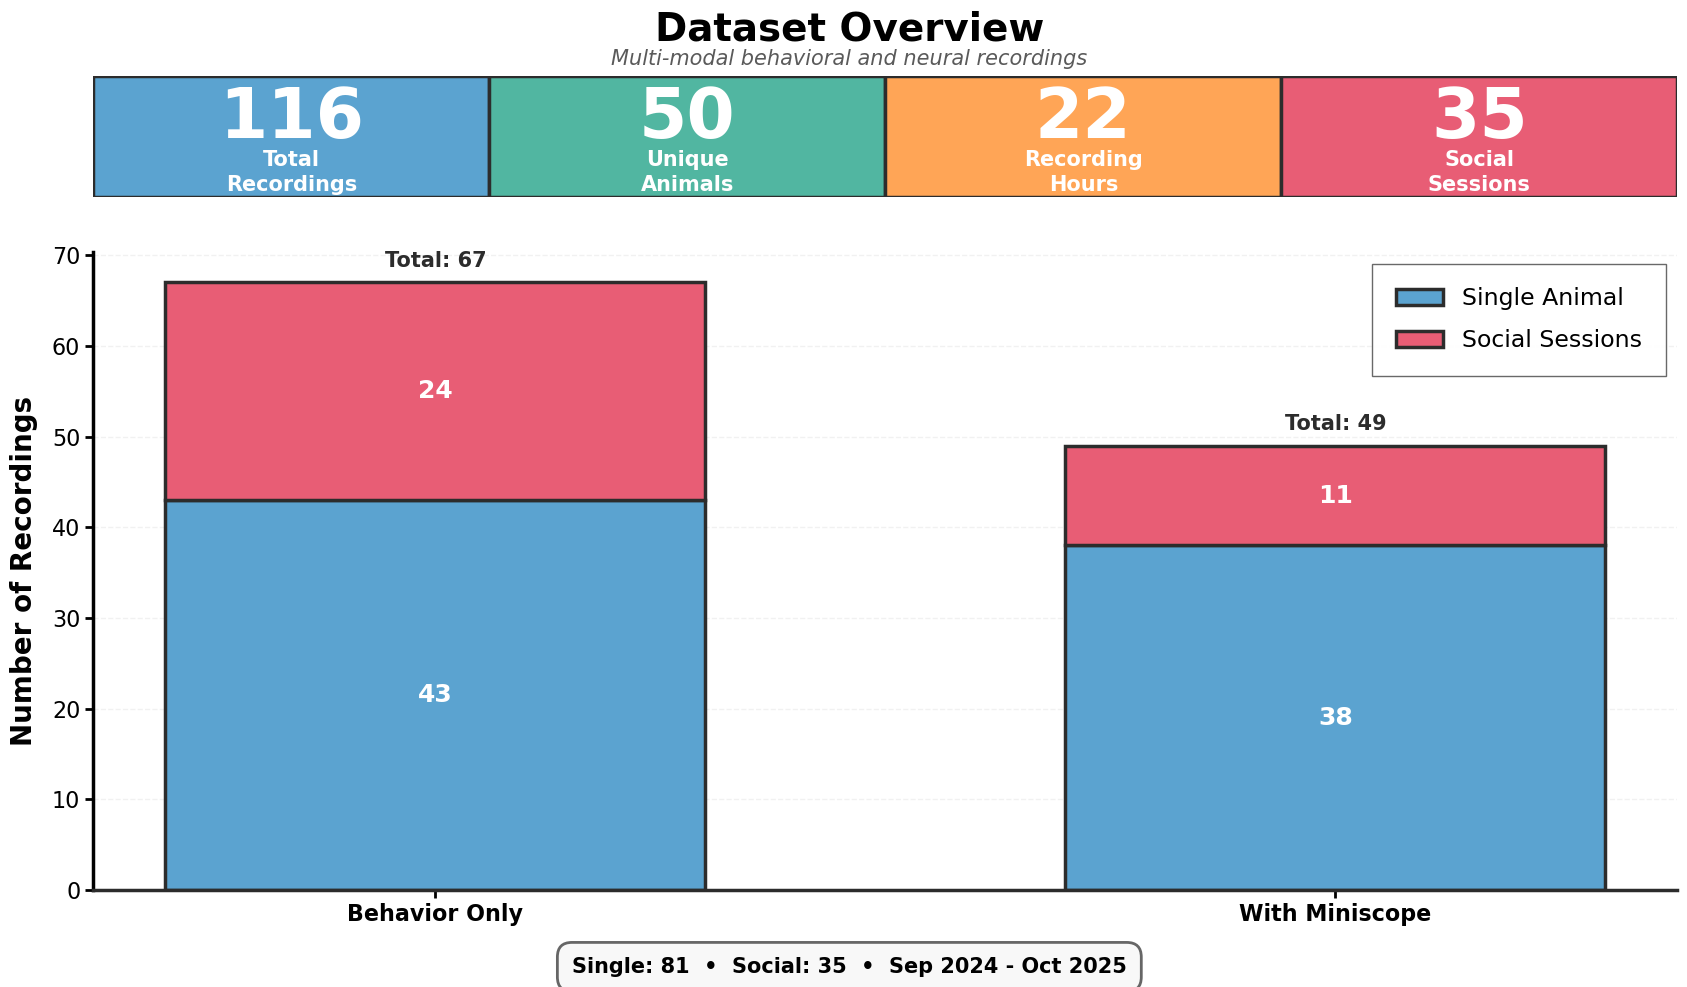

In [20]:
"""
OPTION 1: STACKED COMPOSITION BARS (POSTER VERSION)
====================================================
The cleanest option for poster integration:
- 2 bars (Behavior Only, With Miniscope)
- Each split by Single (blue) vs Social (coral)
- Shows dataset composition at a glance
- Clean, professional, tells a story

Fixed issues:
- Banner text spacing (numbers separated from labels)
- Banner boxes touching (looks better)
- Footer moved away from x-axis
- Meaningful color encoding
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from datetime import datetime

# ============================================================================
# CONFIGURATION
# ============================================================================

# DATASETS = [
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_social_mini", "With Miniscope"),
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_beh_only", "Behavior Only"),
# ]

# OUTPUT_FILE = "/mnt/user-data/outputs/poster_stacked_composition.png"

# ============================================================================
# DATA COLLECTION
# ============================================================================

def get_recording_duration(rec_path):
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    if not os.path.exists(metadata_path):
        return None
    try:
        df = pd.read_csv(metadata_path)
        if 'totalTime' in df.columns:
            return float(df['totalTime'].iloc[0])
        for idx, row in df.iterrows():
            if 'totalTime' in str(row.values):
                for val in row.values:
                    try:
                        return float(val)
                    except:
                        continue
        return None
    except:
        return None

def analyze_dataset(base_path, dataset_name):
    stats = {
        'dataset_name': dataset_name,
        'conditions': {},
        'animals': set(),
        'dates': set(),
        'recording_details': [],
    }
    
    if not os.path.exists(base_path):
        return stats
    
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            duration = get_recording_duration(rec_path)
            
            parts = rec_name.split('_')
            animals_in_rec = []
            date = None
            
            for part in parts:
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
            
            stats['recording_details'].append({
                'condition': condition,
                'duration_seconds': duration,
                'animals': animals_in_rec,
                'date': date,
            })
    
    return stats

print("Analyzing datasets...")
all_stats = []
for base_path, name in DATASETS:
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)

# ============================================================================
# CALCULATE METRICS
# ============================================================================

data = {}
for stats in all_stats:
    dataset_name = stats['dataset_name']
    data[dataset_name] = {}
    
    for condition in ['single', 'social']:
        count = stats['conditions'].get(condition, 0)
        total_seconds = sum(r['duration_seconds'] for r in stats['recording_details'] 
                           if r['condition'] == condition and r['duration_seconds'] is not None)
        hours = total_seconds / 3600
        
        data[dataset_name][condition] = {
            'count': count,
            'hours': hours
        }

# Calculate totals
total_recordings = sum(s['conditions'].get('single', 0) + s['conditions'].get('social', 0) 
                       for s in all_stats)
total_animals = len(set().union(*[s['animals'] for s in all_stats]))
total_hours = sum(sum(r['duration_seconds'] for r in s['recording_details'] 
                      if r['duration_seconds'] is not None) / 3600 for s in all_stats)
total_social = sum(s['conditions'].get('social', 0) for s in all_stats)
total_single = sum(s['conditions'].get('single', 0) for s in all_stats)

# Date range
all_dates = set().union(*[s['dates'] for s in all_stats])
all_dates_sorted = sorted(all_dates)
if all_dates_sorted:
    first_date = datetime.strptime(all_dates_sorted[0], '%Y%m%d').strftime('%b %Y')
    last_date = datetime.strptime(all_dates_sorted[-1], '%Y%m%d').strftime('%b %Y')
    date_span = f"{first_date} - {last_date}"
else:
    date_span = "N/A"

print(f"\nMetrics:")
print(f"  Recordings: {total_recordings}")
print(f"  Animals: {total_animals}")
print(f"  Hours: {total_hours:.1f}")

# ============================================================================
# CREATE FIGURE
# ============================================================================

fig = plt.figure(figsize=(18, 11))

# Banner and chart axes
ax_banner = plt.axes([0.08, 0.78, 0.88, 0.11])
ax_banner.set_xlim(0, 1)
ax_banner.set_ylim(0, 1)
ax_banner.axis('off')

ax_chart = plt.axes([0.08, 0.15, 0.88, 0.58])

# Title
fig.text(0.5, 0.95, 'Dataset Overview', 
         fontsize=28, fontweight='bold', ha='center', va='top')
fig.text(0.5, 0.915, 'Multi-modal behavioral and neural recordings', 
         fontsize=15, ha='center', va='top', style='italic', color='#5A5A5A')

# ============================================================================
# BANNER with FIXED spacing
# ============================================================================

metrics = [
    (total_recordings, 'Total\nRecordings', '#5BA3D0'),
    (total_animals, 'Unique\nAnimals', '#51B6A1'),
    (int(total_hours), 'Recording\nHours', '#FFA556'),
    (total_social, 'Social\nSessions', '#E85D75'),
]

box_width = 0.25
box_height = 1.0

for i, (value, label, color) in enumerate(metrics):
    x_start = i * box_width
    
    rect = Rectangle((x_start, 0), box_width, box_height,
                     facecolor=color, edgecolor='#2C2C2C', 
                     linewidth=2.5, transform=ax_banner.transData)
    ax_banner.add_patch(rect)
    
    # FIXED: More space between number and label
    ax_banner.text(x_start + box_width/2, 0.65, str(value),
                  fontsize=50, fontweight='bold', color='white',
                  ha='center', va='center', transform=ax_banner.transData)
    
    ax_banner.text(x_start + box_width/2, 0.20, label,
                  fontsize=15, fontweight='bold', color='white',
                  ha='center', va='center', transform=ax_banner.transData,
                  linespacing=1.3)

# ============================================================================
# STACKED BAR CHART - The Star of the Show!
# ============================================================================

# Prepare data - REORDER: Behavior first, then Miniscope
datasets_ordered = ['Behavior Only', 'With Miniscope']

single_counts = []
social_counts = []

for dataset_name in datasets_ordered:
    single_counts.append(data[dataset_name]['single']['count'])
    social_counts.append(data[dataset_name]['social']['count'])

# Colors: Blue for single, Coral for social (meaningful!)
single_color = '#5BA3D0'
social_color = '#E85D75'

x = np.arange(len(datasets_ordered))
width = 0.6  # Wider bars look better with just 2

# Create stacked bars
bars_single = ax_chart.bar(x, single_counts, width, 
                           label='Single Animal', 
                           color=single_color, 
                           edgecolor='#2C2C2C', linewidth=2.5)

bars_social = ax_chart.bar(x, social_counts, width, 
                           bottom=single_counts,
                           label='Social Sessions', 
                           color=social_color, 
                           edgecolor='#2C2C2C', linewidth=2.5)

# Styling
ax_chart.set_ylabel('Number of Recordings', fontsize=20, fontweight='bold', labelpad=10)
ax_chart.set_xticks(x)
ax_chart.set_xticklabels(datasets_ordered, fontsize=18, fontweight='600')
ax_chart.tick_params(axis='both', labelsize=16, width=2, length=6)

# Legend - clean and clear
ax_chart.legend(loc='upper right', fontsize=17, frameon=True, 
               shadow=False, fancybox=False, framealpha=0.98, 
               edgecolor='#666666', borderpad=1.0, labelspacing=0.8)

# Spines
ax_chart.spines['top'].set_visible(False)
ax_chart.spines['right'].set_visible(False)
ax_chart.spines['left'].set_linewidth(2.5)
ax_chart.spines['bottom'].set_linewidth(2.5)
ax_chart.spines['bottom'].set_color('#2C2C2C')

# Subtle grid
ax_chart.grid(axis='y', alpha=0.2, linestyle='--', linewidth=1.0, color='#BBBBBB')
ax_chart.set_axisbelow(True)

# Value labels on each segment
for i, (bar, count) in enumerate(zip(bars_single, single_counts)):
    height = bar.get_height()
    # Put label in middle of single section
    ax_chart.text(bar.get_x() + bar.get_width()/2, height/2,
                 f'{count}',
                 ha='center', va='center', fontweight='bold', 
                 fontsize=18, color='white')

for i, (bar, count) in enumerate(zip(bars_social, social_counts)):
    height = bar.get_height()
    # Put label in middle of social section
    y_pos = single_counts[i] + height/2
    ax_chart.text(bar.get_x() + bar.get_width()/2, y_pos,
                 f'{count}',
                 ha='center', va='center', fontweight='bold', 
                 fontsize=18, color='white')

# Total labels on top
for i in range(len(datasets_ordered)):
    total = single_counts[i] + social_counts[i]
    ax_chart.text(x[i], total + max(single_counts)*0.03,
                 f'Total: {total}',
                 ha='center', va='bottom', fontweight='bold', 
                 fontsize=15, color='#2C2C2C')

# ============================================================================
# FOOTER with MORE space
# ============================================================================

fig.text(0.5, 0.08,
         f'Single: {total_single}  •  Social: {total_social}  •  {date_span}',
         fontsize=15, ha='center', va='center', fontweight='600',
         bbox=dict(boxstyle='round,pad=0.7', facecolor='#F8F8F8', 
                  edgecolor='#666666', linewidth=2.0))

# ============================================================================
# SAVE
# ============================================================================

plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', facecolor='white', 
           pad_inches=0.25)
print(f"\n✓ Stacked composition chart saved: {OUTPUT_FILE}")
print("\nThis version shows:")
print("  • Dataset composition (single vs social)")
print("  • Clear visual hierarchy")
print("  • Meaningful color encoding")
print("  • Perfect for poster integration!")

Analyzing datasets...

✓ Comprehensive dataset paper figure saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/poster_option1.png

This figure includes:
  A. KPI metrics banner
  B. Dataset composition (% breakdown)
  C. Total scale comparison (dual axis)
  D. Duration distribution (violin plots)
  E. Temporal collection pattern

Ready for dataset paper!


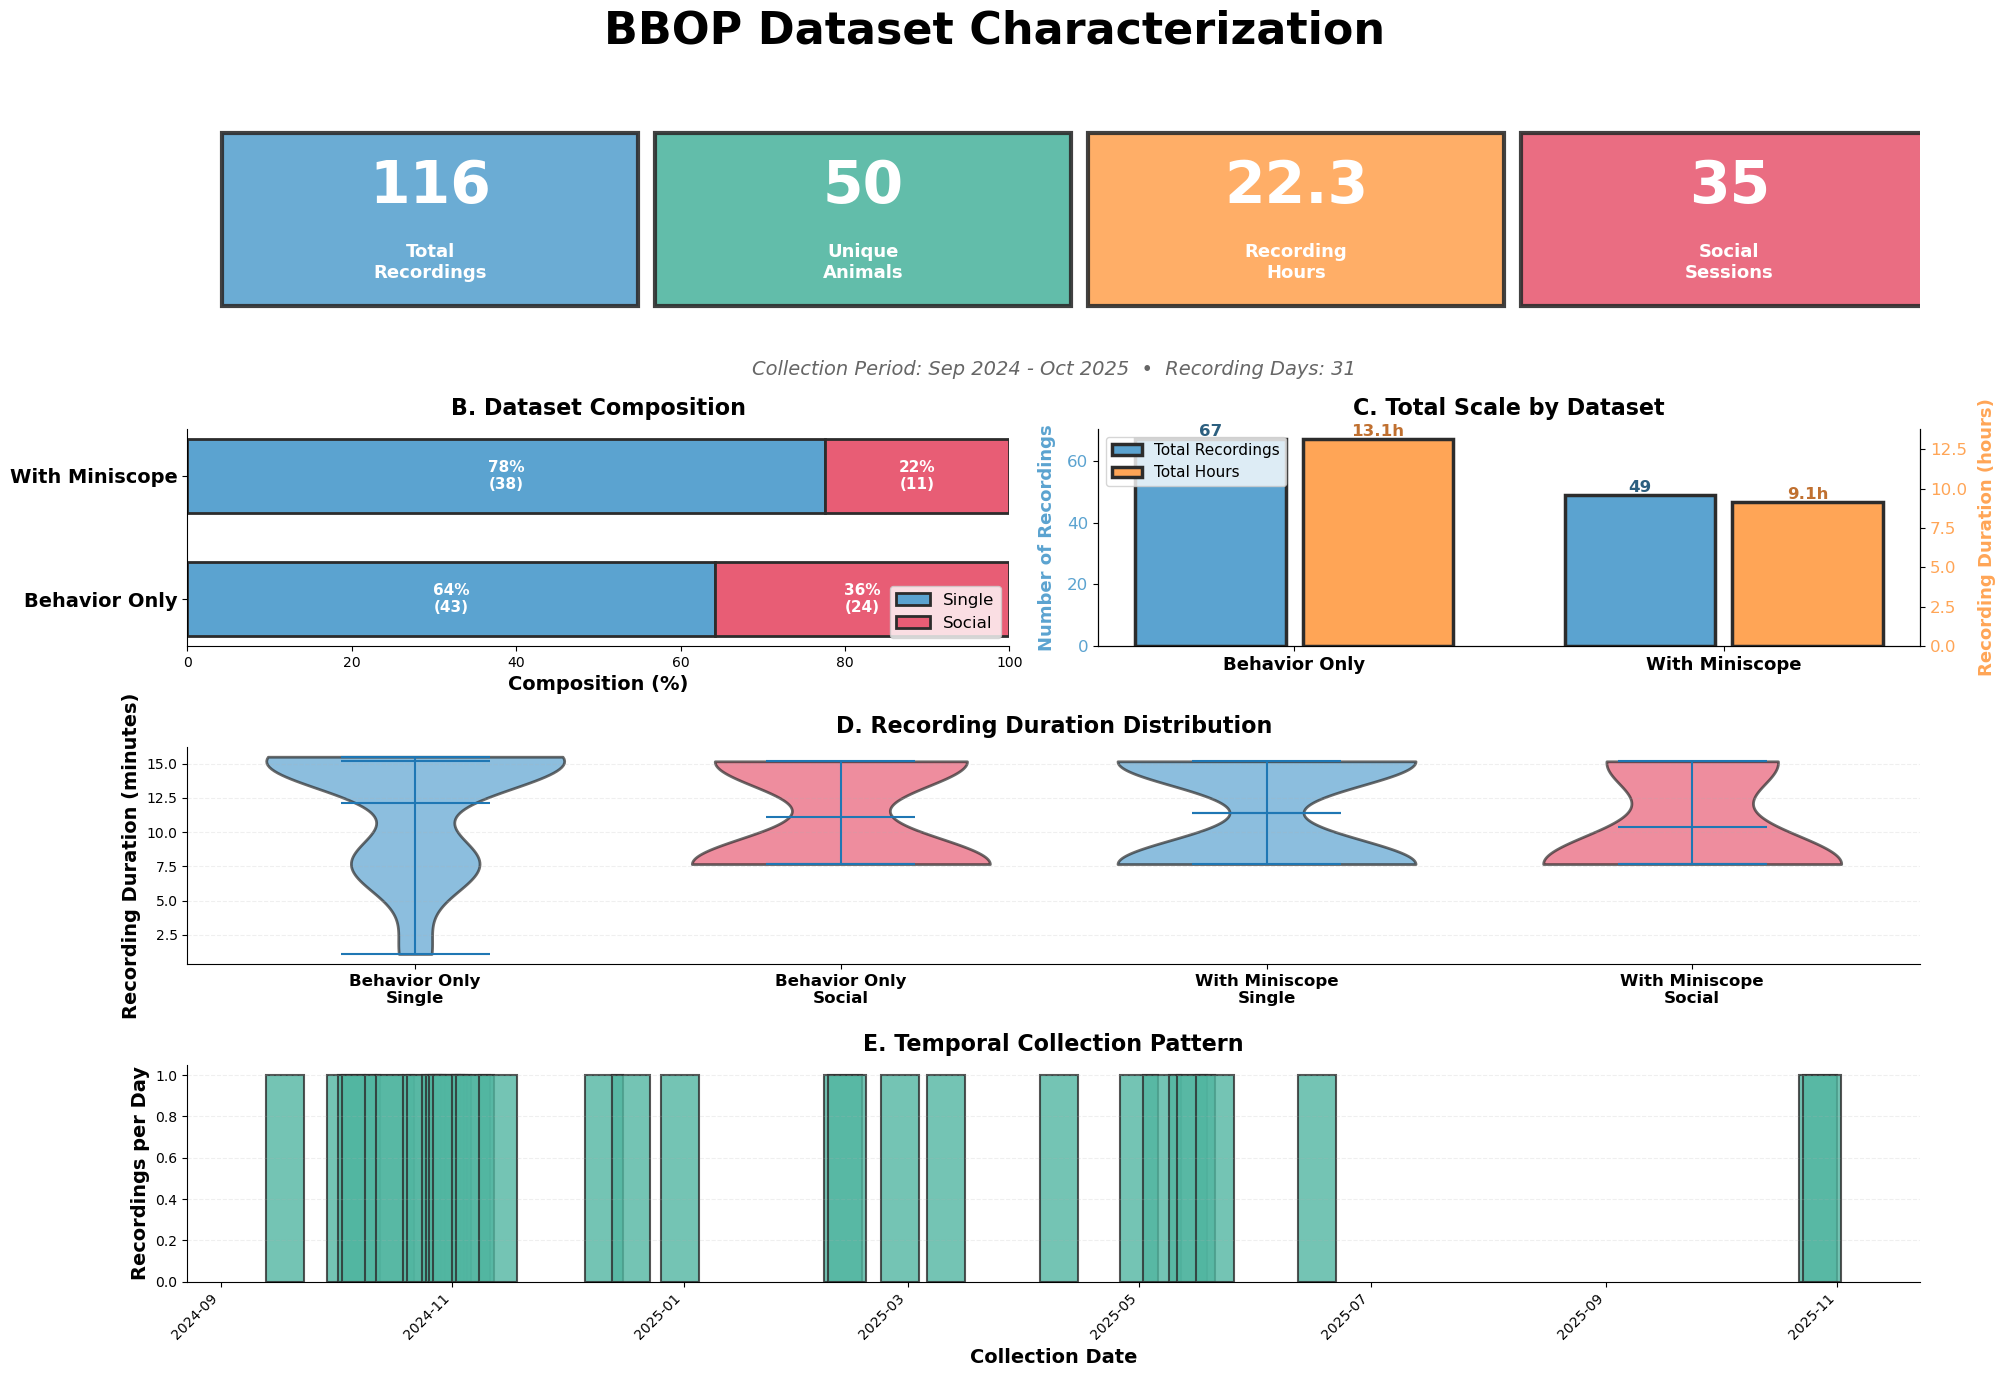

In [21]:
"""
COMPREHENSIVE DATASET PAPER FIGURE
===================================
Full multi-panel figure following GPT's suggestions:
- Panel A: Headline KPI metrics (top banner)
- Panel B: Dataset composition (stacked bars with percentages)
- Panel C: Total scale comparison (dual axis done right)
- Panel D: Recording duration distribution (violin/box plots)
- Panel E: Temporal collection pattern (optional)

This is the "dataset paper grade" version with all the details.
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Wedge
import matplotlib.patches as mpatches
import numpy as np
from datetime import datetime
from collections import Counter

# ============================================================================
# CONFIGURATION
# ============================================================================

# DATASETS = [
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_social_mini", "With Miniscope"),
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_beh_only", "Behavior Only"),
# ]

# OUTPUT_FILE = "/mnt/user-data/outputs/dataset_paper_comprehensive.png"

# ============================================================================
# DATA COLLECTION
# ============================================================================

def get_recording_duration(rec_path):
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    if not os.path.exists(metadata_path):
        return None
    try:
        df = pd.read_csv(metadata_path)
        if 'totalTime' in df.columns:
            return float(df['totalTime'].iloc[0])
        for idx, row in df.iterrows():
            if 'totalTime' in str(row.values):
                for val in row.values:
                    try:
                        return float(val)
                    except:
                        continue
        return None
    except:
        return None

def analyze_dataset(base_path, dataset_name):
    stats = {
        'dataset_name': dataset_name,
        'conditions': {},
        'animals': set(),
        'dates': set(),
        'recording_details': [],
    }
    
    if not os.path.exists(base_path):
        return stats
    
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            duration = get_recording_duration(rec_path)
            
            parts = rec_name.split('_')
            animals_in_rec = []
            date = None
            
            for part in parts:
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
            
            stats['recording_details'].append({
                'condition': condition,
                'duration_seconds': duration,
                'animals': animals_in_rec,
                'date': date,
            })
    
    return stats

print("Analyzing datasets...")
all_stats = []
for base_path, name in DATASETS:
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)

# ============================================================================
# CALCULATE METRICS
# ============================================================================

data = {}
duration_data = {}

for stats in all_stats:
    dataset_name = stats['dataset_name']
    data[dataset_name] = {}
    duration_data[dataset_name] = {'single': [], 'social': []}
    
    for condition in ['single', 'social']:
        count = stats['conditions'].get(condition, 0)
        total_seconds = sum(r['duration_seconds'] for r in stats['recording_details'] 
                           if r['condition'] == condition and r['duration_seconds'] is not None)
        hours = total_seconds / 3600
        
        # Collect individual durations for violin plots
        durations_minutes = [r['duration_seconds']/60 for r in stats['recording_details']
                            if r['condition'] == condition and r['duration_seconds'] is not None]
        duration_data[dataset_name][condition] = durations_minutes
        
        data[dataset_name][condition] = {
            'count': count,
            'hours': hours
        }

# Calculate totals
total_recordings = sum(s['conditions'].get('single', 0) + s['conditions'].get('social', 0) 
                       for s in all_stats)
total_animals = len(set().union(*[s['animals'] for s in all_stats]))
total_hours = sum(sum(r['duration_seconds'] for r in s['recording_details'] 
                      if r['duration_seconds'] is not None) / 3600 for s in all_stats)
total_social = sum(s['conditions'].get('social', 0) for s in all_stats)
total_single = sum(s['conditions'].get('single', 0) for s in all_stats)

# Date range
all_dates = set().union(*[s['dates'] for s in all_stats])
all_dates_sorted = sorted(all_dates)
if all_dates_sorted:
    first_date = datetime.strptime(all_dates_sorted[0], '%Y%m%d').strftime('%b %Y')
    last_date = datetime.strptime(all_dates_sorted[-1], '%Y%m%d').strftime('%b %Y')
    date_span = f"{first_date} - {last_date}"
else:
    date_span = "N/A"

# ============================================================================
# CREATE COMPREHENSIVE FIGURE
# ============================================================================

fig = plt.figure(figsize=(20, 14))

# Create grid for subplots
# Top: KPI banner (spans full width)
# Middle: 2x2 grid of analysis panels
# Bottom: temporal analysis (optional)

ax_kpi = plt.subplot2grid((4, 2), (0, 0), colspan=2, rowspan=1)
ax_composition = plt.subplot2grid((4, 2), (1, 0))
ax_scale = plt.subplot2grid((4, 2), (1, 1))
ax_duration = plt.subplot2grid((4, 2), (2, 0), colspan=2)
ax_temporal = plt.subplot2grid((4, 2), (3, 0), colspan=2)

# Main title
fig.suptitle('BBOP Dataset Characterization', fontsize=32, fontweight='bold', y=0.98)

# ============================================================================
# PANEL A: KPI METRICS BANNER
# ============================================================================

ax_kpi.set_xlim(0, 1)
ax_kpi.set_ylim(0, 1)
ax_kpi.axis('off')

kpi_metrics = [
    (total_recordings, 'Total\nRecordings', '🎥', '#5BA3D0'),
    (total_animals, 'Unique\nAnimals', '🐭', '#51B6A1'),
    (f"{total_hours:.1f}", 'Recording\nHours', '⏱️', '#FFA556'),
    (total_social, 'Social\nSessions', '👥', '#E85D75'),
]

box_width = 0.24
gap = 0.01

for i, (value, label, icon, color) in enumerate(kpi_metrics):
    x_start = i * (box_width + gap) + 0.02
    
    rect = Rectangle((x_start, 0.1), box_width, 0.8,
                     facecolor=color, edgecolor='#2C2C2C', 
                     linewidth=3, transform=ax_kpi.transData, alpha=0.9)
    ax_kpi.add_patch(rect)
    
    ax_kpi.text(x_start + box_width/2, 0.65, str(value),
                fontsize=42, fontweight='bold', color='white',
                ha='center', va='center', transform=ax_kpi.transData)
    
    ax_kpi.text(x_start + box_width/2, 0.30, label,
                fontsize=13, fontweight='bold', color='white',
                ha='center', va='center', transform=ax_kpi.transData,
                linespacing=1.2)

ax_kpi.text(0.5, -0.15, f'Collection Period: {date_span}  •  Recording Days: {len(all_dates)}',
           fontsize=14, ha='center', va='top', transform=ax_kpi.transAxes,
           style='italic', color='#666666')

# ============================================================================
# PANEL B: COMPOSITION (100% Stacked Bars)
# ============================================================================

datasets_ordered = ['Behavior Only', 'With Miniscope']

single_counts = [data[d]['single']['count'] for d in datasets_ordered]
social_counts = [data[d]['social']['count'] for d in datasets_ordered]
totals = [s + so for s, so in zip(single_counts, social_counts)]

# Calculate percentages
single_pcts = [s/t*100 for s, t in zip(single_counts, totals)]
social_pcts = [so/t*100 for so, t in zip(social_counts, totals)]

x = np.arange(len(datasets_ordered))
width = 0.6

bars_single = ax_composition.barh(x, single_pcts, width,
                                  label='Single', color='#5BA3D0',
                                  edgecolor='#2C2C2C', linewidth=2)

bars_social = ax_composition.barh(x, social_pcts, width,
                                  left=single_pcts, label='Social',
                                  color='#E85D75', edgecolor='#2C2C2C', linewidth=2)

ax_composition.set_yticks(x)
ax_composition.set_yticklabels(datasets_ordered, fontsize=14, fontweight='600')
ax_composition.set_xlabel('Composition (%)', fontsize=14, fontweight='bold')
ax_composition.set_title('B. Dataset Composition', fontsize=16, fontweight='bold', pad=10)
ax_composition.legend(loc='lower right', fontsize=12)

# Add percentage labels
for i, (s_pct, so_pct) in enumerate(zip(single_pcts, social_pcts)):
    ax_composition.text(s_pct/2, i, f'{s_pct:.0f}%\n({single_counts[i]})',
                       ha='center', va='center', fontweight='bold',
                       fontsize=11, color='white')
    ax_composition.text(s_pct + so_pct/2, i, f'{so_pct:.0f}%\n({social_counts[i]})',
                       ha='center', va='center', fontweight='bold',
                       fontsize=11, color='white')

ax_composition.set_xlim(0, 100)
ax_composition.spines['top'].set_visible(False)
ax_composition.spines['right'].set_visible(False)

# ============================================================================
# PANEL C: SCALE COMPARISON (Dual Axis)
# ============================================================================

x_scale = np.arange(len(datasets_ordered))
width_scale = 0.35

counts_all = [single_counts[i] + social_counts[i] for i in range(len(datasets_ordered))]
hours_all = [data[d]['single']['hours'] + data[d]['social']['hours'] for d in datasets_ordered]

# Left axis: counts
bars_count = ax_scale.bar(x_scale - width_scale/2 - 0.02, counts_all, width_scale,
                          label='Total Recordings', color='#5BA3D0',
                          edgecolor='#2C2C2C', linewidth=2.5)

ax_scale.set_ylabel('Number of Recordings', fontsize=13, fontweight='bold',
                    color='#5BA3D0', labelpad=8)
ax_scale.tick_params(axis='y', labelcolor='#5BA3D0', labelsize=12)

# Right axis: hours
ax_scale2 = ax_scale.twinx()
bars_hours = ax_scale2.bar(x_scale + width_scale/2 + 0.02, hours_all, width_scale,
                           label='Total Hours', color='#FFA556',
                           edgecolor='#2C2C2C', linewidth=2.5)

ax_scale2.set_ylabel('Recording Duration (hours)', fontsize=13, fontweight='bold',
                     color='#FFA556', labelpad=8)
ax_scale2.tick_params(axis='y', labelcolor='#FFA556', labelsize=12)

ax_scale.set_xticks(x_scale)
ax_scale.set_xticklabels(datasets_ordered, fontsize=13, fontweight='600')
ax_scale.set_title('C. Total Scale by Dataset', fontsize=16, fontweight='bold', pad=10)

# Value labels
for bar, count in zip(bars_count, counts_all):
    height = bar.get_height()
    ax_scale.text(bar.get_x() + bar.get_width()/2, height,
                 f'{count}', ha='center', va='bottom',
                 fontweight='bold', fontsize=12, color='#2C5F7F')

for bar, hrs in zip(bars_hours, hours_all):
    height = bar.get_height()
    ax_scale2.text(bar.get_x() + bar.get_width()/2, height,
                  f'{hrs:.1f}h', ha='center', va='bottom',
                  fontweight='bold', fontsize=12, color='#C07030')

ax_scale.spines['top'].set_visible(False)
ax_scale2.spines['top'].set_visible(False)

# Combined legend
lines1, labels1 = ax_scale.get_legend_handles_labels()
lines2, labels2 = ax_scale2.get_legend_handles_labels()
ax_scale.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

# ============================================================================
# PANEL D: DURATION DISTRIBUTION (Violin Plots)
# ============================================================================

# Prepare data for violin plots
plot_data = []
plot_labels = []
plot_colors = []

for dataset in datasets_ordered:
    for condition in ['single', 'social']:
        if duration_data[dataset][condition]:  # Only if data exists
            plot_data.append(duration_data[dataset][condition])
            plot_labels.append(f"{dataset}\n{condition.capitalize()}")
            plot_colors.append('#5BA3D0' if condition == 'single' else '#E85D75')

positions = np.arange(len(plot_data))

# Create violin plots
parts = ax_duration.violinplot(plot_data, positions=positions, widths=0.7,
                               showmeans=True, showextrema=True, showmedians=True)

# Color the violin plots
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(plot_colors[i])
    pc.set_edgecolor('#2C2C2C')
    pc.set_alpha(0.7)
    pc.set_linewidth(2)

ax_duration.set_xticks(positions)
ax_duration.set_xticklabels(plot_labels, fontsize=12, fontweight='600')
ax_duration.set_ylabel('Recording Duration (minutes)', fontsize=14, fontweight='bold')
ax_duration.set_title('D. Recording Duration Distribution', fontsize=16, fontweight='bold', pad=10)
ax_duration.grid(axis='y', alpha=0.2, linestyle='--')
ax_duration.spines['top'].set_visible(False)
ax_duration.spines['right'].set_visible(False)

# ============================================================================
# PANEL E: TEMPORAL PATTERN (Recording dates histogram)
# ============================================================================

if all_dates:
    dates_datetime = [datetime.strptime(d, '%Y%m%d') for d in all_dates_sorted]
    
    # Count recordings per date
    date_counts = Counter(all_dates)
    dates_for_plot = [datetime.strptime(d, '%Y%m%d') for d in sorted(date_counts.keys())]
    counts_for_plot = [date_counts[d] for d in sorted(date_counts.keys())]
    
    ax_temporal.bar(dates_for_plot, counts_for_plot, width=10, 
                   color='#51B6A1', edgecolor='#2C2C2C', linewidth=1.5, alpha=0.8)
    
    ax_temporal.set_xlabel('Collection Date', fontsize=14, fontweight='bold')
    ax_temporal.set_ylabel('Recordings per Day', fontsize=14, fontweight='bold')
    ax_temporal.set_title('E. Temporal Collection Pattern', fontsize=16, fontweight='bold', pad=10)
    ax_temporal.grid(axis='y', alpha=0.2, linestyle='--')
    ax_temporal.spines['top'].set_visible(False)
    ax_temporal.spines['right'].set_visible(False)
    
    # Rotate date labels
    plt.setp(ax_temporal.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ============================================================================
# SAVE
# ============================================================================

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ Comprehensive dataset paper figure saved: {OUTPUT_FILE}")
print("\nThis figure includes:")
print("  A. KPI metrics banner")
print("  B. Dataset composition (% breakdown)")
print("  C. Total scale comparison (dual axis)")
print("  D. Duration distribution (violin plots)")
print("  E. Temporal collection pattern")
print("\nReady for dataset paper!")

Analyzing datasets...

Metrics:
  Recordings: 116
  Animals: 50
  Hours: 22.3

✓ Clean horizontal composition chart saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/poster_option1.png

Fixed issues:
  ✓ No overlapping text
  ✓ Thinner bars with better spacing
  ✓ Clean, organized layout
  ✓ Removed redundancy
  ✓ Professional aesthetics
  ✓ Better proportions throughout


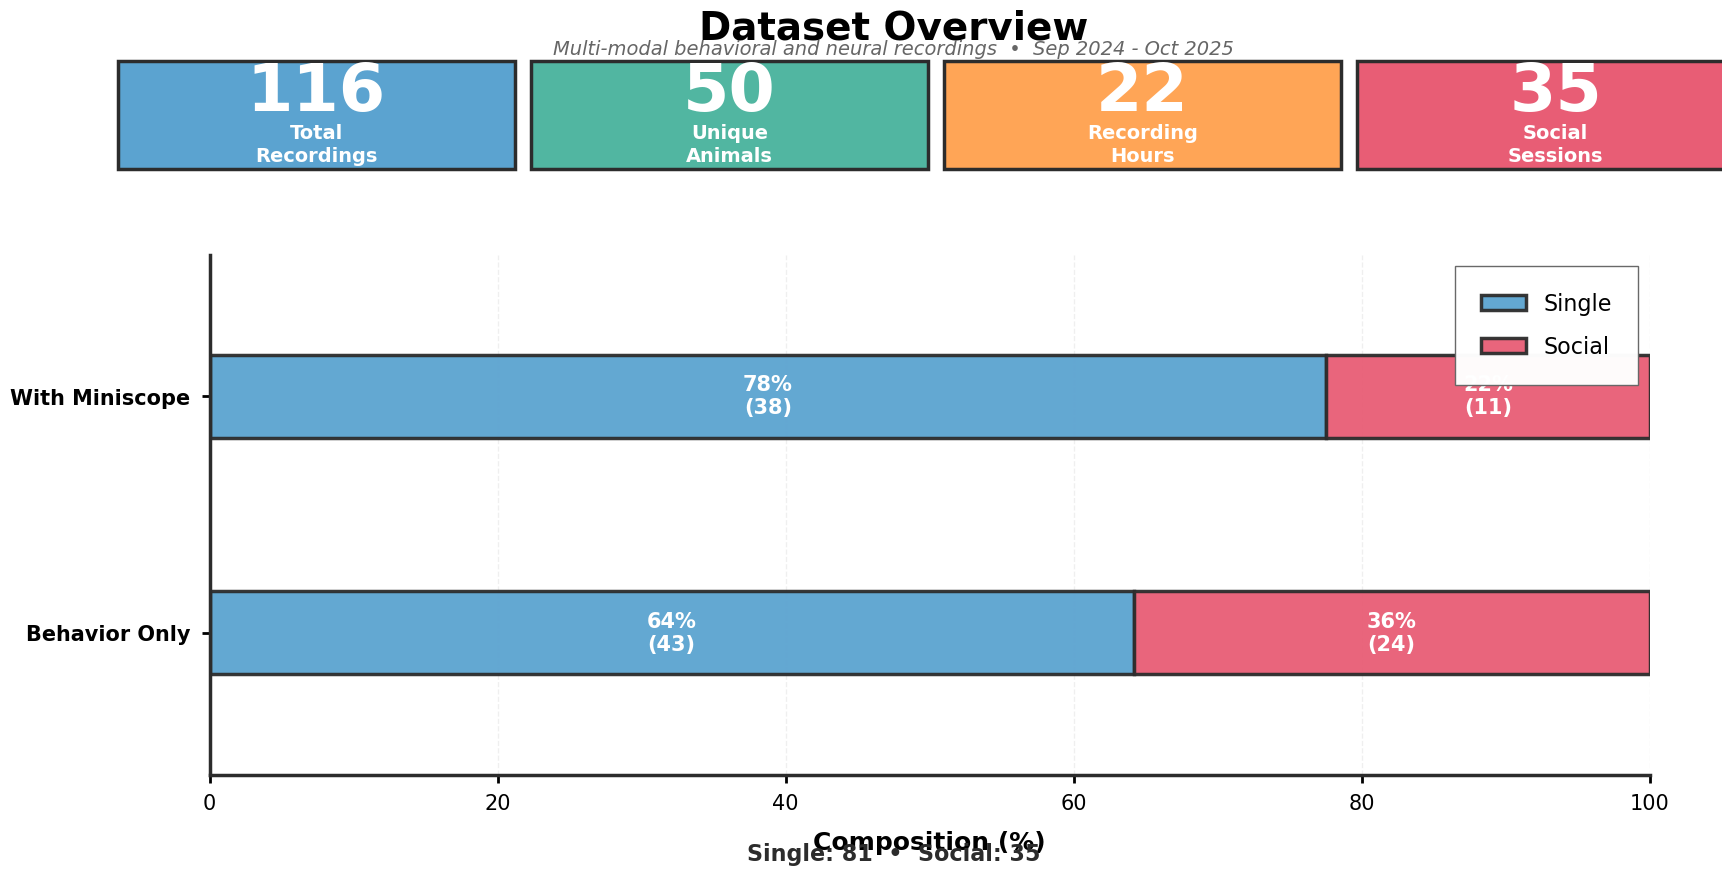

In [25]:
"""
POSTER VERSION - CLEAN HORIZONTAL COMPOSITION
==============================================
Fixed all spacing and aesthetic issues:
- Thinner bars with proper spacing between them
- No overlapping text
- Clean, organized layout
- Removed redundant footer
- Better legend placement
- Professional spacing throughout
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from datetime import datetime

# ============================================================================
# CONFIGURATION
# ============================================================================

# DATASETS = [
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_social_mini", "With Miniscope"),
#     ("/hpc/group/tdunn/Bryan_Rigs/BigOpenField/cleaned/oct3v1_beh_only", "Behavior Only"),
# ]

# OUTPUT_FILE = "/mnt/user-data/outputs/poster_horizontal_clean.png"

# ============================================================================
# DATA COLLECTION
# ============================================================================

def get_recording_duration(rec_path):
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    if not os.path.exists(metadata_path):
        return None
    try:
        df = pd.read_csv(metadata_path)
        if 'totalTime' in df.columns:
            return float(df['totalTime'].iloc[0])
        for idx, row in df.iterrows():
            if 'totalTime' in str(row.values):
                for val in row.values:
                    try:
                        return float(val)
                    except:
                        continue
        return None
    except:
        return None

def analyze_dataset(base_path, dataset_name):
    stats = {
        'dataset_name': dataset_name,
        'conditions': {},
        'animals': set(),
        'dates': set(),
        'recording_details': [],
    }
    
    if not os.path.exists(base_path):
        return stats
    
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            duration = get_recording_duration(rec_path)
            
            parts = rec_name.split('_')
            animals_in_rec = []
            date = None
            
            for part in parts:
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
            
            stats['recording_details'].append({
                'condition': condition,
                'duration_seconds': duration,
                'animals': animals_in_rec,
                'date': date,
            })
    
    return stats

print("Analyzing datasets...")
all_stats = []
for base_path, name in DATASETS:
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)

# ============================================================================
# CALCULATE METRICS
# ============================================================================

data = {}
for stats in all_stats:
    dataset_name = stats['dataset_name']
    data[dataset_name] = {}
    
    for condition in ['single', 'social']:
        count = stats['conditions'].get(condition, 0)
        total_seconds = sum(r['duration_seconds'] for r in stats['recording_details'] 
                           if r['condition'] == condition and r['duration_seconds'] is not None)
        hours = total_seconds / 3600
        
        data[dataset_name][condition] = {
            'count': count,
            'hours': hours
        }

# Calculate totals
total_recordings = sum(s['conditions'].get('single', 0) + s['conditions'].get('social', 0) 
                       for s in all_stats)
total_animals = len(set().union(*[s['animals'] for s in all_stats]))
total_hours = sum(sum(r['duration_seconds'] for r in s['recording_details'] 
                      if r['duration_seconds'] is not None) / 3600 for s in all_stats)
total_social = sum(s['conditions'].get('social', 0) for s in all_stats)
total_single = sum(s['conditions'].get('single', 0) for s in all_stats)

# Date range
all_dates = set().union(*[s['dates'] for s in all_stats])
all_dates_sorted = sorted(all_dates)
if all_dates_sorted:
    first_date = datetime.strptime(all_dates_sorted[0], '%Y%m%d').strftime('%b %Y')
    last_date = datetime.strptime(all_dates_sorted[-1], '%Y%m%d').strftime('%b %Y')
    date_span = f"{first_date} - {last_date}"
else:
    date_span = "N/A"

print(f"\nMetrics:")
print(f"  Recordings: {total_recordings}")
print(f"  Animals: {total_animals}")
print(f"  Hours: {total_hours:.1f}")

# ============================================================================
# CREATE FIGURE WITH PROPER SPACING
# ============================================================================

fig = plt.figure(figsize=(18, 10))

# Better proportions: more space for chart
ax_banner = plt.axes([0.06, 0.80, 0.90, 0.12])  # Banner at top
ax_banner.set_xlim(0, 1)
ax_banner.set_ylim(0, 1)
ax_banner.axis('off')

ax_chart = plt.axes([0.12, 0.20, 0.80, 0.52])  # Chart with good margins

# Title
fig.text(0.5, 0.965, 'Dataset Overview', 
         fontsize=28, fontweight='bold', ha='center', va='top')
fig.text(0.5, 0.935, f'Multi-modal behavioral and neural recordings  •  {date_span}', 
         fontsize=14, ha='center', va='top', style='italic', color='#666666')

# ============================================================================
# BANNER
# ============================================================================

metrics = [
    (total_recordings, 'Total\nRecordings', '#5BA3D0'),
    (total_animals, 'Unique\nAnimals', '#51B6A1'),
    (int(total_hours), 'Recording\nHours', '#FFA556'),
    (total_social, 'Social\nSessions', '#E85D75'),
]

box_width = 0.245
gap = 0.01

for i, (value, label, color) in enumerate(metrics):
    x_start = i * (box_width + gap) + 0.01
    
    rect = Rectangle((x_start, 0.05), box_width, 0.90,
                     facecolor=color, edgecolor='#2C2C2C', 
                     linewidth=2.5, transform=ax_banner.transData)
    ax_banner.add_patch(rect)
    
    ax_banner.text(x_start + box_width/2, 0.68, str(value),
                  fontsize=48, fontweight='bold', color='white',
                  ha='center', va='center', transform=ax_banner.transData)
    
    ax_banner.text(x_start + box_width/2, 0.25, label,
                  fontsize=14, fontweight='bold', color='white',
                  ha='center', va='center', transform=ax_banner.transData,
                  linespacing=1.3)

# ============================================================================
# HORIZONTAL BARS - CLEAN AND WELL-SPACED
# ============================================================================

# Reorder: Behavior Only first (top), then With Miniscope
datasets_ordered = ['Behavior Only', 'With Miniscope']

single_counts = []
social_counts = []
totals = []

for dataset in datasets_ordered:
    single_count = data[dataset]['single']['count']
    social_count = data[dataset]['social']['count']
    total = single_count + social_count
    
    single_counts.append(single_count)
    social_counts.append(social_count)
    totals.append(total)

# Calculate percentages
single_pcts = [s/t*100 for s, t in zip(single_counts, totals)]
social_pcts = [so/t*100 for so, t in zip(social_counts, totals)]

# Colors
single_color = '#5BA3D0'
social_color = '#E85D75'

y = np.arange(len(datasets_ordered))
height = 0.35  # THINNER bars (was 0.5)

# Create horizontal stacked bars
bars_single = ax_chart.barh(y, single_pcts, height,
                            label='Single', color=single_color,
                            edgecolor='#2C2C2C', linewidth=2.5, alpha=0.95)

bars_social = ax_chart.barh(y, social_pcts, height,
                            left=single_pcts, label='Social',
                            color=social_color, edgecolor='#2C2C2C', 
                            linewidth=2.5, alpha=0.95)

# Styling
ax_chart.set_xlabel('Composition (%)', fontsize=18, fontweight='bold', labelpad=12)
ax_chart.set_yticks(y)
ax_chart.set_yticklabels(datasets_ordered, fontsize=17, fontweight='600')
ax_chart.tick_params(axis='both', labelsize=15, width=2, length=6, pad=8)
ax_chart.set_xlim(0, 100)
ax_chart.set_ylim(-0.6, 1.6)  # More space above and below bars

# Legend - better position
ax_chart.legend(loc='upper right', fontsize=16, frameon=True, 
               shadow=False, fancybox=False, framealpha=0.98, 
               edgecolor='#666666', borderpad=1.2, labelspacing=0.9,
               bbox_to_anchor=(1.0, 1.0))

# Spines
ax_chart.spines['top'].set_visible(False)
ax_chart.spines['right'].set_visible(False)
ax_chart.spines['left'].set_linewidth(2.5)
ax_chart.spines['bottom'].set_linewidth(2.5)
ax_chart.spines['left'].set_color('#2C2C2C')
ax_chart.spines['bottom'].set_color('#2C2C2C')

# Grid
ax_chart.grid(axis='x', alpha=0.15, linestyle='--', linewidth=1.0, color='#999999')
ax_chart.set_axisbelow(True)

# Add percentage and count labels inside bars
for i, (s_pct, s_count) in enumerate(zip(single_pcts, single_counts)):
    ax_chart.text(s_pct/2, i, f'{s_pct:.0f}%\n({s_count})',
                 ha='center', va='center', fontweight='bold',
                 fontsize=15, color='white')

for i, (s_pct, so_pct, so_count) in enumerate(zip(single_pcts, social_pcts, social_counts)):
    ax_chart.text(s_pct + so_pct/2, i, f'{so_pct:.0f}%\n({so_count})',
                 ha='center', va='center', fontweight='bold',
                 fontsize=15, color='white')

# ============================================================================
# FOOTER - Clean info line
# ============================================================================

fig.text(0.5, 0.12,
         f'Single: {total_single}  •  Social: {total_social}',
         fontsize=16, ha='center', va='center', fontweight='600',
         color='#2C2C2C')

# ============================================================================
# SAVE
# ============================================================================

plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', facecolor='white', 
           pad_inches=0.3)
print(f"\n✓ Clean horizontal composition chart saved: {OUTPUT_FILE}")
print("\nFixed issues:")
print("  ✓ No overlapping text")
print("  ✓ Thinner bars with better spacing")
print("  ✓ Clean, organized layout")
print("  ✓ Removed redundancy")
print("  ✓ Professional aesthetics")
print("  ✓ Better proportions throughout")